# 실험의 전제와 목표

1. **전제** 
    - ImageNet으로 사전학습된 세 모델 ResNet, DenseNet, EfficientNet 각각을 전이학습한다. 
    - 전이학습 방법으로는 Feature Extraction, Partial Fine-Tuning, Full Fine-Tuning을 진행한다. 
    - 이미지 전처리 전략으로는 4 가지를 둔다.
    - 학습은 무료 구독 colab GPU T4에서 진행한다. 
    - 로컬 환경은 mps.

2. **목표**
    - 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
    - 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
    - 결과에 대해 **설명**할 수 있다. 

- **실험 대상 모델**

    | 모델 | 첫 conv | head | Partial에서 푸는 마지막 stage |
    |--|--|--|--|
    | resnet50 | conv1 | fc (2048) | layer4 |
    | densenet121 | features.conv0 | classifier (1024) | features.denseblock4, features.norm5 |
    | efficientnet_b0 | features.0.0 | classifier.1 (1280, 앞 Dropout 유지) | features.7, features.8(마지막 1×1 conv) |

- **실험 대상 전이학습 방법**
    | 학습 방법 | 정의 | 
    | -- | -- |
    | Feature Extraction(Frozen) | 특징 추출기 부분은 완전히 고정하고, 분류기 부분만 ImageNet 가중치 위에서 fine-tuning한다. 
    | Paritial Fine-Tuning | 특징 추출기의 마지막 stage 하나와 분류기 head를 제외한 부분은 freeze. ImageNet 사전학습 가중치 위에서 재학습한다. |
    | Full Fine-Tuning | 모든 가중치를 ImageNet 사전학습 가중치 위에서 Fine-Tuning 한다. | 

- **실험 대상 데이터 전처리 방법** 
    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | pad__none | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | pad__clahe | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | squash__none | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | squash__clahe | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |

---
- ***여유가 되면 추가***: 
    - 사전학습된 U-Net을 정상 폐, 폐렴 폐, 또는 갈비뼈 이미지로 전이학습해 폐 bbox를 추출하도록 학습시킨다.
    - 추출된 bbox 기준 여유 padding을 줘서 갈비뼈 부분만 crop할 수 있도록 한다. 
    - bbox 추출 모델을 활용한 이미지 전처리를 적용했을 때 성능이 얼마나 바뀌는지 실험으로 확인한다. 
    - 10/1 이 U-Net 이용 crop 방식을 EDA는 했으나 실험이 넣지 않은 이유: UNet을 사용한 bbox 검출 crop 방식은 이에 작용할 수 있는 변수가 너무 많다.UNet을 전이학습한 데이터셋의 퀄리티와 그 학습 방법 퀄리티가 본 실험 대상 데이터셋 퀄리티에 너무 큰 영향을 준다. 따라서 UNet을 이용한 데이터 전처리는 데이터셋의 차이로 비교되지 않고, UNet의 성능의 차이로 비교될 여지가 있다는 게 가장 큰 우려다. 
    - 자체적인 폐/갈비뼈 bbox 추론 모델을 안정적으로 구축하기 전까지는 이 실험이 의미가 없다. 

# 0. 공통 실험 인프라 구축
- 상수 모음
- 시드 고정
- colab(cuda)/로컬(mps) 디바이스 설정
- colab/로컬 환경 data/result 드라이브 마운트/경로 설정
- 평가 함수(Accuracy, Precision, Recall, F1, confusion matrix, ROC-AUC)
- best-eval checkpoint 저장이 포함된 train/evaluate 함수

In [1]:
# ---------- import ----------
import copy
import hashlib
import os
import random
import re
import sys
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import WeightedRandomSampler

# ---------- 상수 ----------
SEED = 42
IMG_SIZE = 224
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]          # label index: NORMAL=0, PNEUMONIA=1(positive)
POS_LABEL = 1

# 정규화: 흑백을 3채널로 복제한 뒤 ImageNet 채널별 통계로 정규화한다
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# 데이터 분할 / 전처리 / 증강
VAL_RATIO = 0.1                    # train+val : test ≈ 9:1 이므로 train:val도 9:1
CLAHE_CLIP, CLAHE_TILE = 2.0, (8, 8)  # EDA 3-5와 동일
ROT_DEG = 10                       # 랜덤 회전 범위(±deg)
HFLIP_P = 0.5

BATCH_SIZE = 32

In [2]:
# ---------- 시드 고정 ----------
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)

In [3]:
# ---------- 디바이스: colab(cuda) / 로컬(mps) ----------
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

# ---------- 경로: colab은 Drive 마운트, 로컬은 현재 폴더 ----------
IN_COLAB = "google.colab" in sys.modules
DRIVE_PROJECT = "CodeIT/Colab/mission6_xray"  # MyDrive 아래 프로젝트 폴더명

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive") / DRIVE_PROJECT
else:
    PROJECT_DIR = Path(".")

DATA_DIR = PROJECT_DIR / "data"
RESULT_DIR = PROJECT_DIR / "results"
CACHE_DIR = RESULT_DIR / "cache"            # 전처리 캐시(npz)
CKPT_DIR = RESULT_DIR / "checkpoints"       # best-eval / 재개용 checkpoint
TB_DIR = RESULT_DIR / "runs"                # TensorBoard 로그
HIST_DIR = RESULT_DIR / "history"           # run별 에폭 기록 CSV
for d in (CACHE_DIR, CKPT_DIR, TB_DIR, HIST_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"데이터 폴더가 없습니다: {DATA_DIR.resolve()}"
print(f"device={DEVICE}, colab={IN_COLAB}")
print(f"DATA_DIR={DATA_DIR.resolve()}\nRESULT_DIR={RESULT_DIR.resolve()}")

Mounted at /content/drive
device=cuda, colab=True
DATA_DIR=/content/drive/.shortcut-targets-by-id/1jiBBrf6OgmZHBJwWf7EuOlLaj5uuTyJO/mission6_xray/data
RESULT_DIR=/content/drive/.shortcut-targets-by-id/1jiBBrf6OgmZHBJwWf7EuOlLaj5uuTyJO/mission6_xray/results


In [4]:
# ---------- 평가 함수 ----------
def compute_metrics(y_true, y_prob, threshold: float = 0.5) -> dict:
    """PNEUMONIA(=1)를 positive로 보고 Accuracy / Precision / Recall / F1 / ROC-AUC / confusion matrix를 계산한다."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=POS_LABEL, zero_division=0)
    # 한 클래스만 있는 배치/부분집합에서는 AUC가 정의되지 않는다
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }


def plot_confusion_matrix(cm, title: str = "", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.2))
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], CLASSES)
    ax.set_yticks([0, 1], CLASSES)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    return ax

In [5]:
# ---------- TensorBoard (colab은 기본 설치, 로컬은 pip install tensorboard) ----------
try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    SummaryWriter = None
    print("tensorboard 미설치: 학습 기록은 history DataFrame/CSV에만 남습니다.")


def make_writer(run_name: str, purge_step: int | None = None):
    """purge_step: 재개 시 이 step 이후의 기존 기록(끊긴 세션에서 남은 중복)을 지운다."""
    return SummaryWriter(log_dir=str(TB_DIR / run_name), purge_step=purge_step) if SummaryWriter else None


# ---------- train / evaluate ----------
# 모델은 2-class logits (B, 2)를 출력한다고 가정한다. loader는 (x, y)를 device 위 텐서로 준다.
def set_frozen_eval(model):
    """학습 가능한 파라미터가 하나도 없는 서브모듈(동결된 stage)은 eval로 둔다.
    Frozen/Partial에서 동결 부분의 BN running stats와 StochasticDepth까지 사전학습 상태 그대로 고정하기 위함 (full이면 no-op)."""
    for m in model.modules():
        params = list(m.parameters())
        if params and not any(p.requires_grad for p in params):
            m.eval()


def train_one_epoch(model, loader, criterion, optimizer, device=DEVICE):
    model.train()
    set_frozen_eval(model)
    total_loss, n_correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        n_correct += (logits.argmax(1) == y).sum().item()
        n += y.size(0)
    return {"loss": total_loss / n, "accuracy": n_correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, threshold: float = 0.5):
    """loss + compute_metrics 결과와, 사후 분석용 y_true / y_prob(PNEUMONIA 확률)를 함께 반환한다."""
    model.eval()
    total_loss, n = 0.0, 0
    y_true, y_prob = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += criterion(logits, y).item() * y.size(0)
        n += y.size(0)
        y_true.append(y.cpu())
        y_prob.append(logits.softmax(1)[:, POS_LABEL].cpu())
    y_true = torch.cat(y_true).numpy()
    y_prob = torch.cat(y_prob).numpy()
    metrics = {"loss": total_loss / n, **compute_metrics(y_true, y_prob, threshold)}
    return metrics, y_true, y_prob


# ---------- checkpoint: best(가중치) / last(재개용 전체 상태) ----------
def _atomic_save(obj, path: Path):
    """임시 파일에 쓴 뒤 교체한다. 저장 도중 세션이 끊겨도 기존 파일이 깨지지 않는다."""
    tmp = path.with_name(path.name + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def _get_rng_state(train_loader) -> dict:
    state = {"python": random.getstate(), "numpy": np.random.get_state(), "torch": torch.get_rng_state()}
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    elif torch.backends.mps.is_available():
        state["mps"] = torch.mps.get_rng_state()
    if hasattr(train_loader, "rng_state"):
        state["loader"] = train_loader.rng_state()
    return state


def _set_rng_state(state: dict, train_loader):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"])
    if "cuda" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state["cuda"])
    if "mps" in state and torch.backends.mps.is_available():
        torch.mps.set_rng_state(state["mps"])
    if "loader" in state and hasattr(train_loader, "load_rng_state"):
        train_loader.load_rng_state(state["loader"])


def fit(model, train_loader, val_loader, criterion, optimizer, epochs: int, run_name: str,
        scheduler=None, monitor: str = "f1", tensorboard: bool = True, save_every: int = 3,
        resume: bool = True, device=DEVICE):
    """매 에폭 train/val 지표를 모두 기록하고, val `monitor` 지표가 가장 좋은 에폭의 가중치를 `{run}_best.pt`로 저장한다.
    `save_every` 에폭마다(+마지막 에폭) 재개용 `{run}_last.pt`와 `history/{run}.csv`를 덮어쓰고,
    resume=True면 `{run}_last.pt`에서 이어서 학습한다. 끝나면 best 가중치를 모델에 로드하고 history를 반환한다.
    monitor: "f1" | "recall" | "roc_auc" | "precision" | "accuracy" | "loss"(loss만 최소화)
    optimizer param group에 "name"("head"/"backbone")이 있으면 그룹별 lr을 기록한다.
    """
    model.to(device)
    minimize = monitor == "loss"
    best_path = CKPT_DIR / f"{run_name}_best.pt"
    last_path = CKPT_DIR / f"{run_name}_last.pt"
    hist_path = HIST_DIR / f"{run_name}.csv"
    history, best_state, best_epoch, best_val_metrics = [], None, -1, None
    best_score = float("inf") if minimize else -float("inf")
    start_epoch = 1

    if resume and last_path.exists():
        ck = torch.load(last_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ck["model"])
        optimizer.load_state_dict(ck["optimizer"])
        if scheduler is not None and ck["scheduler"] is not None:
            scheduler.load_state_dict(ck["scheduler"])
        history, best_state = ck["history"], ck["best_state"]
        best_score, best_epoch, best_val_metrics = ck["best_score"], ck["best_epoch"], ck["best_val_metrics"]
        _set_rng_state(ck["rng"], train_loader)
        start_epoch = ck["epoch"] + 1
        # 끊긴 세션이 last 이후에 best를 갱신했을 수 있으므로 last 시점의 best로 되돌린다
        _atomic_save({"state_dict": best_state, "epoch": best_epoch, "monitor": monitor,
                      "val_metrics": best_val_metrics}, best_path)
        print(f"[{run_name}] resume from epoch {ck['epoch']} (best epoch={best_epoch})")

    writer = make_writer(run_name, purge_step=start_epoch) if tensorboard else None
    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        lrs = {g.get("name", f"group{i}"): g["lr"] for i, g in enumerate(optimizer.param_groups)}
        tr = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va, _, _ = evaluate(model, val_loader, criterion, device)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(va["loss"])
            else:
                scheduler.step()

        score = va[monitor]
        # 첫 에폭은 항상 저장한다 (monitor가 NaN이어도 best 가중치가 비지 않도록)
        improved = best_state is None or (score < best_score if minimize else score > best_score)
        val_scalars = {k: v for k, v in va.items() if k != "confusion_matrix"}
        if improved:
            best_score, best_epoch, best_val_metrics = score, epoch, val_scalars
            best_state = copy.deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            _atomic_save({"state_dict": best_state, "epoch": epoch, "monitor": monitor,
                          "val_metrics": val_scalars}, best_path)

        tn, fp, fn, tp = va["confusion_matrix"].ravel().tolist()
        row = {"epoch": epoch,
               "lr_head": lrs.get("head", next(iter(lrs.values()))), "lr_backbone": lrs.get("backbone", float("nan")),
               "train_loss": tr["loss"], "train_accuracy": tr["accuracy"],
               **{f"val_{k}": v for k, v in val_scalars.items()},
               "val_tn": tn, "val_fp": fp, "val_fn": fn, "val_tp": tp,
               "is_best": improved, "sec": time.time() - t0}
        history.append(row)

        if writer is not None:
            writer.add_scalars("loss", {"train": tr["loss"], "val": va["loss"]}, epoch)
            writer.add_scalars("accuracy", {"train": tr["accuracy"], "val": va["accuracy"]}, epoch)
            for k in ("precision", "recall", "f1", "roc_auc"):
                writer.add_scalar(f"val/{k}", va[k], epoch)
            writer.add_scalars("lr", {k: v for k, v in lrs.items()}, epoch)

        if epoch % save_every == 0 or epoch == epochs:
            pd.DataFrame(history).to_csv(hist_path, index=False)
            _atomic_save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                          "scheduler": scheduler.state_dict() if scheduler is not None else None,
                          "epoch": epoch, "history": history,
                          "best_state": best_state, "best_score": best_score, "best_epoch": best_epoch,
                          "best_val_metrics": best_val_metrics, "rng": _get_rng_state(train_loader)}, last_path)

        print(f"[{run_name}] ep {epoch:02d} | train loss {tr['loss']:.4f} acc {tr['accuracy']:.3f} | "
              f"val loss {va['loss']:.4f} acc {va['accuracy']:.3f} rec {va['recall']:.3f} "
              f"f1 {va['f1']:.3f} auc {va['roc_auc']:.3f} | {row['sec']:.0f}s" + (" *" if improved else ""))

    if writer is not None:
        writer.close()
    model.load_state_dict(best_state)
    print(f"[{run_name}] best epoch={best_epoch} ({monitor}={best_score:.4f}) -> {best_path}")
    return pd.DataFrame(history)

# 1. 데이터 전처리
- **데이터 재분할:**
    - train+val 합친 후 split한다. 
    - person id 그룹 기준으로 나눈다. 동일 id가 train/val에 섞여들어가지 않도록 한다. 
- **test 해시 기준 중복 이미지 제거**
    - EDA에서 확인한 중복 이미지 6장에서 한 장만 남기고 제거한다. 
- **소수 클래스(NORMAL) 가중치**
    - WeightedRandomSampler를 활용한다. 
- **전처리 데이터셋 변형 정의:**
    - 고정할 것:
        - Normalization: ImageNet 통계 기준으로 정규화한다. 
            - 근거: 전이학습 대상 데이터와 ImageNet 통계 데이터 기준 정규화 간에 차이가 거의 없었다. 따라서 사전학습 가중치에 맞는 정규화 방식을 사용하는 것으로 한다. 
        - data channel: 3채널로 고정한다. 
            - 근거: 사전학습 첫번째 conv 레이어가 3채널을 받도록 설계되어있다. 그리고 따라서 1채널을 넣으려면 첫 번쨰 conv 레이어를 1채널을 받도록 수정해서 넣어야 하고, 이 때 가중치는 W_R * g + W_G * g + W_B * g  =  (W_R + W_G + W_B) * g 이 공식을 써서 합산해서 1채널 필터로 만든다. 즉 3채널에 같은 이미지를 넣는 것과, RGB가중치를 더한 1채널 필터에 한 번에 넣는 것은 같은 계산이다. 1ch VS 3ch 비교는 사실상 같은 모델을 두 번 돌리는 것에 가깝다. 
        - Augmentation: 데이터 증강은 안정적인 Rotation + Hflip으로 진행한다. 과적합을 방지하는 데에 도움을 줌이 저번 실험으로 증명되었기 때문이다. 

    - 변수로 처리할 것:
        - **CLAHE: 적용 vs 미적용**
            - 목표: CLAHE로 국소부위 콘트라스트를 올리는 게 성능에 영향을 주는 지 확인한다. 
        - **Sizing: 비율 유지 패딩(224,224) vs squash(224,224)**
            - 목표: EDA에서 수립한 가설인, "클래스 별로 이미지 크기와 종횡비 차이가 구분되기 때문에 이것이 성능에 영향을 줄것이다"라는 가설이 성립하는 지 확인한다. 
            - 우려: test 세트도 종횡비 차이가 나기 때문에 현재 갖고있는 데이터들로는 아주 객관적으로 확인하기 힘들것이라는 게 우려사항이다. 

- **실험 대상 데이터 전처리 방법**
    | 전처리 방법 | Channel | Sizing | Equalization | Augmentation | Normalization | 
    | -- | -- | -- | -- | -- | -- |
    | pad__none | 3채널 | 비율 유지 패딩 | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | pad__clahe | 3채널 | 비율 유지 패딩 | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |
    | squash__none | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE X | rotation + Hflip | ImageNet 통계 기준 |
    | squash__clahe | 3채널 | 224×224 직접 리사이즈(squash, 종횡비 무시) | CLAHE O | rotation + Hflip | ImageNet 통계 기준 |

In [6]:
# ---------- 메타 수집: 경로 / 라벨 / 환자 그룹 / (test) 픽셀 해시 ----------
PERSON_RE = re.compile(r"person(\d+)_(bacteria|virus)_(\d+)")
NORMAL_RE = re.compile(r"^(.*IM-\d+)-")   # NORMAL은 person id 대신 'IM-0523' 같은 접두가 환자 번호 역할을 한다


def group_key(cls: str, filename: str) -> str:
    m = PERSON_RE.match(filename) if cls == "PNEUMONIA" else NORMAL_RE.match(filename)
    return f"{cls}/{m.group(1)}" if m else f"{cls}/{filename}"   # 매칭 실패 시 단독 그룹


def pixel_md5(path) -> str:
    with Image.open(path) as im:
        return hashlib.md5(np.asarray(im.convert("L")).tobytes()).hexdigest()


def build_meta() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label, cls in enumerate(CLASSES):
            for p in sorted((DATA_DIR / split / cls).glob("*.jpeg")):
                rows.append({"rel_path": f"{split}/{cls}/{p.name}", "orig_split": split, "cls": cls,
                             "label": label, "group": group_key(cls, p.name)})
    meta = pd.DataFrame(rows)
    # 픽셀 해시는 test 중복 제거에만 필요하다 (EDA 5-1과 같은 convert("L") 기준)
    is_test = meta["orig_split"] == "test"
    meta.loc[is_test, "pixel_md5"] = [pixel_md5(DATA_DIR / r) for r in meta.loc[is_test, "rel_path"]]
    return meta


meta = build_meta()
display(pd.crosstab(meta["orig_split"], meta["cls"]).reindex(SPLITS))

cls,NORMAL,PNEUMONIA
orig_split,,
train,1341,3875
val,8,8
test,234,390


In [7]:
# ---------- 데이터 재분할: train+val을 합친 뒤 환자 그룹 단위로 9:1 층화 분할 ----------
pool = meta[meta["orig_split"] != "test"].reset_index(drop=True)
sgkf = StratifiedGroupKFold(n_splits=round(1 / VAL_RATIO), shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(pool, pool["label"], groups=pool["group"]))
train_df = pool.iloc[tr_idx].reset_index(drop=True)
val_df = pool.iloc[va_idx].reset_index(drop=True)

leak = set(train_df["group"]) & set(val_df["group"])
assert not leak, f"train/val에 같은 그룹이 섞였습니다: {list(leak)[:5]}"

ct = pd.DataFrame({name: df["cls"].value_counts().reindex(CLASSES)
                   for name, df in [("train", train_df), ("val", val_df)]}).T
display(pd.concat({"count": ct, "ratio": ct.div(ct.sum(axis=1), axis=0).round(3)}, axis=1)
        .assign(total=ct.sum(axis=1), groups=[train_df["group"].nunique(), val_df["group"].nunique()]))

count            ratio           total groups
cls   NORMAL PNEUMONIA NORMAL PNEUMONIA             
train   1211      3514  0.256     0.744  4725   2577
val      138       369  0.272     0.728   507    284

In [8]:
# ---------- test 해시 기준 중복 이미지 제거: 중복 그룹마다 첫 장만 남긴다 ----------
test_all = meta[meta["orig_split"] == "test"]
dup_mask = test_all.duplicated("pixel_md5", keep="first")
print(f"test: {len(test_all)} -> {len(test_all) - dup_mask.sum()} (중복 {dup_mask.sum()}장 제거)")
display(test_all[test_all.duplicated("pixel_md5", keep=False)]
        .assign(removed=dup_mask)[["rel_path", "cls", "pixel_md5", "removed"]])
test_df = test_all[~dup_mask].reset_index(drop=True)

test: 624 -> 618 (중복 6장 제거)


,rel_path,cls,pixel_md5,removed
5326,test/NORMAL/NORMAL2-IM-0095-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,False
5327,test/NORMAL/NORMAL2-IM-0096-0001.jpeg,NORMAL,490238debf98e38314601339655f5d7a,True
5349,test/NORMAL/NORMAL2-IM-0173-0001-0001.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,False
5350,test/NORMAL/NORMAL2-IM-0173-0001-0002.jpeg,NORMAL,bcd47182e622a00b47ca8a483736af8c,True
5370,test/NORMAL/NORMAL2-IM-0246-0001-0001.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,False
5371,test/NORMAL/NORMAL2-IM-0246-0001-0002.jpeg,NORMAL,46c9cc352433b6d00234274328e74334,True
5551,test/PNEUMONIA/person128_bacteria_606.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,False
5552,test/PNEUMONIA/person128_bacteria_607.jpeg,PNEUMONIA,2f340970400a806e8a5ee314a48aaf27,True
5569,test/PNEUMONIA/person134_bacteria_643.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,False
5570,test/PNEUMONIA/person134_bacteria_644.jpeg,PNEUMONIA,a285a7d87f39959bf7567703a3b1bab4,True


In [9]:
# ---------- 전처리 (a) 결정적 단계를 1회만 계산해 캐시 ----------
# 흑백 변환 -> (CLAHE: 원본 해상도에서 적용) -> sizing(pad / squash) 224.
# 매 에폭 같은 결과가 나오는 단계라 JPEG 디코딩/CLAHE/resize 비용을 학습 루프에서 제거한다.
# pad와 squash는 같은 보간(PIL BILINEAR)을 쓰고, 종횡비를 지키는지만 다르다.
VARIANTS = {  # name: (sizing, clahe)
    "pad__none": ("pad", False),
    "pad__clahe": ("pad", True),
    "squash__none": ("squash", False),
    "squash__clahe": ("squash", True),
}


def resize_pad(gray: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """긴 변을 size에 맞추고 남는 영역을 0(검정)으로 채운다. EDA 3-6의 resize_pad와 같다."""
    im = Image.fromarray(gray)
    w, h = im.size
    s = size / max(w, h)
    im = im.resize((max(1, round(w * s)), max(1, round(h * s))), Image.BILINEAR)
    canvas = Image.new("L", (size, size), 0)
    canvas.paste(im, ((size - im.width) // 2, (size - im.height) // 2))
    return np.asarray(canvas)


def resize_squash(gray: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """종횡비를 무시하고 size x size로 바로 리사이즈한다(패딩 없음)."""
    return np.asarray(Image.fromarray(gray).resize((size, size), Image.BILINEAR))


SIZERS = {"pad": resize_pad, "squash": resize_squash}


def _preprocess_one(rel_path: str) -> dict:
    with Image.open(DATA_DIR / rel_path) as im:
        gray = np.asarray(im.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)  # 스레드마다 별도 객체
    eq = {False: gray, True: clahe.apply(gray)}
    return {name: SIZERS[sizing](eq[use_clahe]) for name, (sizing, use_clahe) in VARIANTS.items()}


def load_or_build_cache(rel_paths, force: bool = False) -> dict:
    """{variant: uint8 (N,224,224)}. 순서는 rel_paths와 같다."""
    path = CACHE_DIR / f"preprocessed_v2_{IMG_SIZE}.npz"
    rel_paths = np.asarray(rel_paths)
    if path.exists() and not force:
        z = np.load(path)
        if np.array_equal(z["rel_paths"], rel_paths) and all(k in z for k in VARIANTS):
            return {k: z[k] for k in VARIANTS}
        print("캐시의 이미지 목록/변형이 달라 다시 만듭니다.")

    t0 = time.time()
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:   # PIL 디코딩/cv2는 GIL을 놓아서 스레드로 병렬화된다
        out = list(ex.map(_preprocess_one, rel_paths, chunksize=32))
    cache = {k: np.stack([o[k] for o in out]) for k in VARIANTS}
    np.savez(path, rel_paths=rel_paths, **cache)
    print(f"캐시 생성: {len(rel_paths)}장, {time.time() - t0:.0f}s -> {path}")
    return cache


# train / val / test 전체를 한 배열에 담고, 각 split은 인덱스로 가리킨다
all_df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")],
                   ignore_index=True)
CACHE = load_or_build_cache(sorted(all_df["rel_path"]))
_pos = {p: i for i, p in enumerate(sorted(all_df["rel_path"]))}
all_df["cache_idx"] = all_df["rel_path"].map(_pos)
print({k: (v.shape, v.dtype, f"{v.nbytes / 1e6:.0f}MB") for k, v in CACHE.items()})

{'pad__none': ((5850, 224, 224), dtype('uint8'), '294MB'), 'pad__clahe': ((5850, 224, 224), dtype('uint8'), '294MB'), 'squash__none': ((5850, 224, 224), dtype('uint8'), '294MB'), 'squash__clahe': ((5850, 224, 224), dtype('uint8'), '294MB')}


In [10]:
# ---------- 전처리 (b) 데이터 GPU 상주 + (c) 배치 단위 GPU 증강/정규화 ----------
# 모든 모델 x 전이학습 방법 x 전처리 변형이 같은 캐시 -> 같은 증강 -> 같은 sampler를 탄다.
# sampler / 증강 난수는 run마다 시드 고정된 전용 Generator(CPU)에서 뽑는다.
# 같은 시드면 모든 변형이 같은 샘플 순서와 같은 증강 파라미터를 받고, 이미지의 전처리만 다르다.
_DEVICE_IMAGES = {}   # 현재 변형 하나만 device에 둔다 (그리드는 변형 순으로 돌아 교체가 적다)


def device_images(variant: str) -> torch.Tensor:
    if variant not in _DEVICE_IMAGES:
        _DEVICE_IMAGES.clear()
        _DEVICE_IMAGES[variant] = torch.from_numpy(CACHE[variant]).unsqueeze(1).to(DEVICE)  # uint8 (N,1,H,W)
    return _DEVICE_IMAGES[variant]


class GpuTransform:
    """uint8 (B,1,H,W) -> 3채널 복제 + ImageNet 정규화 텐서 (B,3,H,W).
    train이면 샘플별 회전(±ROT_DEG) + 좌우반전을 한 번의 affine으로 적용한다."""

    def __init__(self, train: bool, generator: torch.Generator | None = None):
        self.train, self.gen = train, generator
        self.mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, -1, 1, 1)
        self.std = torch.tensor(IMAGENET_STD, device=DEVICE).view(1, -1, 1, 1)

    def augment(self, x):
        b = x.size(0)
        # 배치 전체가 아니라 샘플마다 각도/반전을 따로 뽑는다
        angle = (torch.rand(b, generator=self.gen) * 2 - 1) * np.deg2rad(ROT_DEG)
        flip = torch.where(torch.rand(b, generator=self.gen) < HFLIP_P, -1.0, 1.0)
        cos, sin = torch.cos(angle), torch.sin(angle)
        theta = torch.zeros(b, 2, 3)
        theta[:, 0, 0], theta[:, 0, 1] = cos * flip, -sin
        theta[:, 1, 0], theta[:, 1, 1] = sin * flip, cos
        grid = F.affine_grid(theta.to(x.device), list(x.shape), align_corners=False)
        return F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)  # 바깥은 배경 0

    def __call__(self, x_uint8):
        x = x_uint8.float().div_(255)
        if self.train:
            x = self.augment(x)
        return (x.expand(-1, 3, -1, -1) - self.mean) / self.std


class GpuBatchLoader:
    """device에 올라간 이미지 텐서에서 인덱스로 배치를 꺼낸다. DataLoader의 워커/collate/전송 비용이 없다."""

    def __init__(self, images, indices, labels, transform, batch_size=BATCH_SIZE, sampler=None):
        self.images = images
        self.indices = torch.tensor(indices, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.labels_dev = self.labels.to(DEVICE)
        self.transform, self.batch_size, self.sampler = transform, batch_size, sampler

    def __len__(self):
        n = len(self.sampler) if self.sampler is not None else len(self.indices)
        return (n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        order = (torch.as_tensor(list(self.sampler), dtype=torch.long) if self.sampler is not None
                 else torch.arange(len(self.indices)))
        for s in range(0, len(order), self.batch_size):
            pos = order[s:s + self.batch_size]
            x = self.images[self.indices[pos].to(DEVICE)]
            yield self.transform(x), self.labels_dev[pos.to(DEVICE)]

    def rng_state(self) -> dict:
        """재개용: sampler / 증강 Generator 상태."""
        gens = {"sampler": getattr(self.sampler, "generator", None), "augment": self.transform.gen}
        return {k: g.get_state() for k, g in gens.items() if g is not None}

    def load_rng_state(self, state: dict):
        gens = {"sampler": getattr(self.sampler, "generator", None), "augment": self.transform.gen}
        for k, g in gens.items():
            if g is not None and k in state:
                g.set_state(state[k])


def make_loaders(variant: str, batch_size: int = BATCH_SIZE, seed: int = SEED):
    """variant: VARIANTS의 키. train은 WeightedRandomSampler(클래스 역빈도)로 NORMAL을 더 자주 뽑는다."""
    images = device_images(variant)
    aug_gen = torch.Generator().manual_seed(seed)
    sampler_gen = torch.Generator().manual_seed(seed)

    loaders = {}
    for split in ["train", "val", "test"]:
        df = all_df[all_df["split"] == split]
        is_train = split == "train"
        sampler = None
        if is_train:
            class_w = 1.0 / np.bincount(df["label"], minlength=len(CLASSES))
            sampler = WeightedRandomSampler(class_w[df["label"].to_numpy()], num_samples=len(df),
                                            replacement=True, generator=sampler_gen)
        loaders[split] = GpuBatchLoader(images, df["cache_idx"].to_numpy(), df["label"].to_numpy(),
                                        GpuTransform(train=is_train, generator=aug_gen if is_train else None),
                                        batch_size=batch_size, sampler=sampler)
    return loaders

pad__none     shape=(32, 3, 224, 224) mean=-0.345 std=1.301
pad__clahe    shape=(32, 3, 224, 224) mean=-0.314 std=1.318
squash__none  shape=(32, 3, 224, 224) mean=0.080 std=1.115
squash__clahe shape=(32, 3, 224, 224) mean=0.122 std=1.128


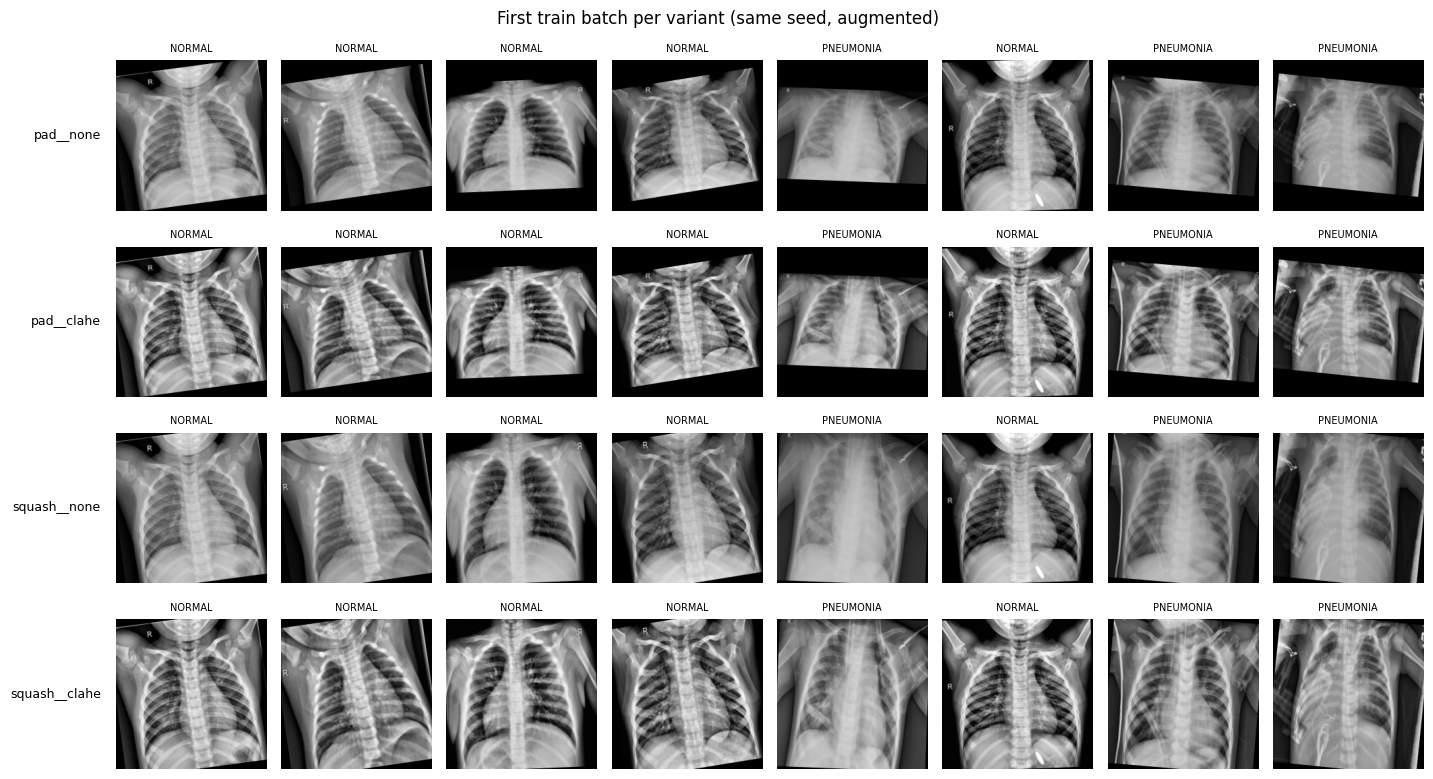

모든 변형의 첫 배치 라벨 순서 동일
train epoch sampled class ratio: {'NORMAL': '0.499', 'PNEUMONIA': '0.501'}
loader + augmentation only: 0.45s / epoch (148 batches)


In [11]:
# ---------- 확인: 변형별 train 배치 / 변형 간 샘플 순서 동일성 / sampler 클래스 비율 / 로더 속도 ----------
N_SHOW = 8


def to_display(x):
    """정규화를 되돌려 첫 채널만 [0,1] 흑백으로 본다."""
    return (x[:, 0] * IMAGENET_STD[0] + IMAGENET_MEAN[0]).clamp(0, 1).cpu().numpy()


# 같은 시드라 열마다 같은 이미지·같은 증강이 나온다 -> 행끼리 pad/squash, none/clahe 차이만 보인다
fig, axes = plt.subplots(len(VARIANTS), N_SHOW, figsize=(N_SHOW * 1.8, len(VARIANTS) * 2.0))
first_labels = {}
for r, name in enumerate(VARIANTS):
    x, y = next(iter(make_loaders(name)["train"]))
    first_labels[name] = y.cpu()
    print(f"{name:13s} shape={tuple(x.shape)} mean={x.mean():.3f} std={x.std():.3f}")
    imgs = to_display(x[:N_SHOW])
    for c, ax in enumerate(axes[r]):
        ax.imshow(imgs[c], cmap="gray", vmin=0, vmax=1)
        ax.set_title(CLASSES[y[c]], fontsize=7)
        ax.axis("off")
    axes[r][0].text(-0.1, 0.5, name, transform=axes[r][0].transAxes, ha="right", va="center", fontsize=9)
plt.suptitle("First train batch per variant (same seed, augmented)")
plt.tight_layout()
plt.show()

ref = next(iter(first_labels.values()))
assert all(torch.equal(ref, y) for y in first_labels.values()), "변형마다 sampler 순서가 다릅니다"
print("모든 변형의 첫 배치 라벨 순서 동일")

# sampler 적용 후 한 에폭 동안 뽑힌 클래스 비율과, 로더+증강만의 에폭 소요 시간
loader = make_loaders("pad__clahe")["train"]
t0 = time.time()
counts = torch.zeros(len(CLASSES), dtype=torch.long)
for x, y in loader:
    counts += torch.bincount(y.cpu(), minlength=len(CLASSES))
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
elif DEVICE.type == "mps":
    torch.mps.synchronize()
print("train epoch sampled class ratio:", {c: f"{n / counts.sum().item():.3f}" for c, n in zip(CLASSES, counts.tolist())})
print(f"loader + augmentation only: {time.time() - t0:.2f}s / epoch ({len(loader)} batches)")

# 2. 모델 정의

In [12]:
# ---------- 아키텍처별 이름 정리 ----------
# head: 2-class Linear로 교체할 분류층
# last_stage: Partial Fine-Tuning에서 head와 함께 푸는 특징 추출기의 마지막 stage (pooling 직전까지)
import torchvision.models as tvm

ARCH_SPECS = {
    "resnet50": {"ctor": tvm.resnet50, "weights": tvm.ResNet50_Weights.DEFAULT,
                 "head": "fc",
                 "last_stage": ["layer4"]},
    "densenet121": {"ctor": tvm.densenet121, "weights": tvm.DenseNet121_Weights.DEFAULT,
                    "head": "classifier",
                    "last_stage": ["features.denseblock4", "features.norm5"]},       # norm5: 마지막 block 뒤 BN
    "efficientnet_b0": {"ctor": tvm.efficientnet_b0, "weights": tvm.EfficientNet_B0_Weights.DEFAULT,
                        "head": "classifier.1",         # classifier.0 Dropout은 유지
                        "last_stage": ["features.7", "features.8"]},                  # 8: 마지막 1x1 conv(320->1280)
}
MODES = ["frozen", "partial", "full"]


def _set_submodule(model: nn.Module, name: str, module: nn.Module):
    parent, _, child = name.rpartition(".")
    setattr(model.get_submodule(parent) if parent else model, child, module)


def _under(param_name: str, prefixes) -> bool:
    return any(param_name == p or param_name.startswith(p + ".") for p in prefixes)


def build_model(arch: str, mode: str, pretrained: bool = True) -> nn.Module:
    """ImageNet 사전학습 모델 -> head를 2-class로 교체 -> 동결 모드 적용. 입력은 3채널."""
    spec = ARCH_SPECS[arch]
    model = spec["ctor"](weights=spec["weights"] if pretrained else None)

    head = model.get_submodule(spec["head"])
    _set_submodule(model, spec["head"], nn.Linear(head.in_features, len(CLASSES)))

    trainable = {"frozen": [spec["head"]], "partial": spec["last_stage"] + [spec["head"]], "full": None}[mode]
    for name, p in model.named_parameters():
        p.requires_grad = trainable is None or _under(name, trainable)
    return model


def split_params(model: nn.Module, arch: str):
    """(head 파라미터, 학습되는 backbone 파라미터) — optimizer의 차등 LR 그룹에 쓴다."""
    head_prefix = [ARCH_SPECS[arch]["head"]]
    head, backbone = [], []
    for name, p in model.named_parameters():
        if p.requires_grad:
            (head if _under(name, head_prefix) else backbone).append(p)
    return head, backbone

In [13]:
# ---------- 확인: 모드별 학습 파라미터 수 / forward 출력 shape ----------
rows = []
for arch in ARCH_SPECS:
    for mode in MODES:
        m = build_model(arch, mode)
        head, backbone = split_params(m, arch)
        total = sum(p.numel() for p in m.parameters())
        n_head, n_backbone = sum(p.numel() for p in head), sum(p.numel() for p in backbone)
        rows.append({"arch": arch, "mode": mode, "total(M)": total / 1e6, "trainable(M)": (n_head + n_backbone) / 1e6,
                     "head": n_head, "backbone(M)": n_backbone / 1e6, "trainable %": 100 * (n_head + n_backbone) / total})
display(pd.DataFrame(rows).round(3))

x, _ = next(iter(make_loaders("pad__none")["val"]))
for arch in ARCH_SPECS:
    m = build_model(arch, "full").to(DEVICE).eval()
    with torch.no_grad():
        logits = m(x)
    assert logits.shape == (x.size(0), len(CLASSES))
    print(f"{arch:16s} input {tuple(x.shape)} -> logits {tuple(logits.shape)}")
    del m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s] 


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 115MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 137MB/s]


,arch,mode,total(M),trainable(M),head,backbone(M),trainable %
0,resnet50,frozen,23.512,0.004,4098,0.000,0.017
1,resnet50,partial,23.512,14.969,4098,14.965,63.664
2,resnet50,full,23.512,23.512,4098,23.508,100.000
3,densenet121,frozen,6.956,0.002,2050,0.000,0.029
4,densenet121,partial,6.956,2.162,2050,2.160,31.084
5,densenet121,full,6.956,6.956,2050,6.954,100.000
6,efficientnet_b0,frozen,4.010,0.003,2562,0.000,0.064
7,efficientnet_b0,partial,4.010,1.132,2562,1.129,28.228
8,efficientnet_b0,full,4.010,4.010,2562,4.008,100.000


resnet50         input (32, 3, 224, 224) -> logits (32, 2)
densenet121      input (32, 3, 224, 224) -> logits (32, 2)
efficientnet_b0  input (32, 3, 224, 224) -> logits (32, 2)


# 3. 모델 학습
- 모델 기록은 텐서보드로 기록한다. 
- 코랩 무료 계정을 사용하기 때문에 3~5epoch마다 모델 가중치와 학습 기록을 저장해야 한다. 중간에 세션이 끊겼을 때 부작용을 최소화하고 다른 세션에서 학습을 바로 이어갈 수 있도록. 

In [14]:
# ---------- 학습 설정: 36 run(3모델 x 3모드 x 4변형) 모두 동일 ----------
ARCHS = list(ARCH_SPECS)
EPOCHS = 10                       # 고정 에폭, early stopping 없음 (best-val checkpoint로 선택)
LR_HEAD, LR_BACKBONE = 1e-3, 1e-4  # 새로 만든 head는 크게, 사전학습 backbone은 작게 — 이 규칙을 모든 모델/모드에 똑같이 적용
WEIGHT_DECAY = 1e-4
SAVE_EVERY = 3                    # colab 세션 끊김 대비: 3 에폭마다 재개용 checkpoint + history CSV 저장
MONITOR = "f1"
SUMMARY_PATH = RESULT_DIR / "summary.csv"   # 완료 run 요약 (여기 있는 run은 다시 돌리지 않는다)


def run_name_of(arch: str, mode: str, variant: str) -> str:
    return f"{arch}__{mode}__{variant}"


def make_optimizer(model: nn.Module, arch: str):
    head, backbone = split_params(model, arch)
    groups = [{"name": "head", "params": head, "lr": LR_HEAD}]
    if backbone:   # frozen은 backbone 그룹이 없다
        groups.append({"name": "backbone", "params": backbone, "lr": LR_BACKBONE})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)


def completed_runs() -> set:
    return set(pd.read_csv(SUMMARY_PATH)["run"]) if SUMMARY_PATH.exists() else set()

In [15]:
# ---------- run 하나: 학습 -> summary.csv 1행 추가 -> 재개용 checkpoint 삭제 ----------
def run_experiment(arch: str, mode: str, variant: str, epochs: int = EPOCHS):
    run = run_name_of(arch, mode, variant)
    sizing, clahe = VARIANTS[variant]
    seed_everything(SEED)   # head 초기화 / dropout 난수까지 run마다 같은 출발점
    loaders = make_loaders(variant)
    model = build_model(arch, mode).to(DEVICE)
    optimizer = make_optimizer(model, arch)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = fit(model, loaders["train"], loaders["val"], nn.CrossEntropyLoss(), optimizer, epochs, run,
                  scheduler=scheduler, monitor=MONITOR, save_every=SAVE_EVERY, resume=True)

    best = history[history["is_best"]].iloc[-1]
    row = {"run": run, "arch": arch, "mode": mode, "variant": variant, "sizing": sizing, "clahe": clahe,
           "epochs": epochs, "monitor": MONITOR, "best_epoch": int(best["epoch"]),
           **{c: best[c] for c in history.columns if c.startswith("val_")},
           "params_total": sum(p.numel() for p in model.parameters()),
           "params_trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
           "mean_epoch_sec": history["sec"].mean(), "total_sec": history["sec"].sum(),
           "finished_at": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")}
    pd.DataFrame([row]).to_csv(SUMMARY_PATH, mode="a", header=not SUMMARY_PATH.exists(), index=False)
    (CKPT_DIR / f"{run}_last.pt").unlink(missing_ok=True)   # 완료됐으니 재개용 상태는 지운다 (best/history는 유지)
    return model, history

In [16]:
# ---------- 그리드 실행: 세션이 끊기면 이 셀만 다시 실행 ----------
# 완료 run(summary.csv에 있음)은 건너뛰고, 진행 중이던 run은 {run}_last.pt에서 이어간다.
# 같은 변형끼리 연달아 돌려 GPU에 올린 이미지 텐서를 재사용한다.
RUN_ONLY = None   # 일부만 돌릴 때: 예) {"arch": ["resnet50"], "mode": ["full"]}

grid = [(variant, arch, mode) for variant in VARIANTS for arch in ARCHS for mode in MODES]
done = completed_runs()
for variant, arch, mode in grid:
    cond = {"variant": variant, "arch": arch, "mode": mode}
    if RUN_ONLY and any(cond[k] not in v for k, v in RUN_ONLY.items()):
        continue
    run = run_name_of(arch, mode, variant)
    if run in done:
        print(f"[{run}] 완료됨 - skip")
        continue
    model, _ = run_experiment(arch, mode, variant)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()

[resnet50__frozen__pad__none] ep 01 | train loss 0.2614 acc 0.908 | val loss 0.6429 acc 0.740 rec 0.642 f1 0.782 auc 0.976 | 15s *
[resnet50__frozen__pad__none] ep 02 | train loss 0.1592 acc 0.943 | val loss 0.5471 acc 0.791 rec 0.713 f1 0.832 auc 0.981 | 15s *
[resnet50__frozen__pad__none] ep 03 | train loss 0.1342 acc 0.950 | val loss 0.5354 acc 0.799 rec 0.724 f1 0.840 auc 0.984 | 15s *
[resnet50__frozen__pad__none] ep 04 | train loss 0.1238 acc 0.956 | val loss 0.3509 acc 0.856 rec 0.805 f1 0.891 auc 0.986 | 16s *
[resnet50__frozen__pad__none] ep 05 | train loss 0.1037 acc 0.964 | val loss 0.3485 acc 0.860 rec 0.810 f1 0.894 auc 0.987 | 17s *
[resnet50__frozen__pad__none] ep 06 | train loss 0.1062 acc 0.963 | val loss 0.3901 acc 0.852 rec 0.799 f1 0.887 auc 0.987 | 17s
[resnet50__frozen__pad__none] ep 07 | train loss 0.0926 acc 0.970 | val loss 0.3724 acc 0.858 rec 0.808 f1 0.892 auc 0.987 | 19s
[resnet50__frozen__pad__none] ep 08 | train loss 0.0974 acc 0.966 | val loss 0.3554 acc

In [17]:
# ---------- 진행 현황 ----------
# TensorBoard: 4장 첫 셀(start_tensorboard)로 띄운다. colab이면 로컬 브라우저용 공개 URL도 만든다.
if SUMMARY_PATH.exists():
    summary = pd.read_csv(SUMMARY_PATH)
    print(f"완료 {len(summary)} / {len(VARIANTS) * len(ARCHS) * len(MODES)} run")
    display(summary[["run", "best_epoch", "val_recall", "val_f1", "val_roc_auc", "val_accuracy", "mean_epoch_sec"]]
            .sort_values("val_f1", ascending=False).round(4))
else:
    print("아직 완료된 run이 없습니다.")

완료 36 / 36 run


,run,best_epoch,val_recall,val_f1,val_roc_auc,val_accuracy,mean_epoch_sec
29,resnet50__full__squash__clahe,8,0.9946,0.9932,0.9976,0.9901,64.7193
26,efficientnet_b0__full__squash__none,10,0.9919,0.9932,0.9993,0.9901,26.8909
32,densenet121__full__squash__clahe,1,0.9946,0.9919,0.9967,0.9882,56.0217
20,resnet50__full__squash__none,6,0.9919,0.9919,0.9983,0.9882,64.8018
2,resnet50__full__pad__none,10,0.9892,0.9918,0.9974,0.9882,64.5119
5,densenet121__full__pad__none,1,0.9946,0.9906,0.9972,0.9862,55.5922
19,resnet50__partial__squash__none,7,0.9946,0.9906,0.9967,0.9862,26.0175
14,densenet121__full__pad__clahe,1,0.9919,0.9905,0.9973,0.9862,55.8914
23,densenet121__full__squash__none,5,0.9919,0.9905,0.9978,0.9862,55.9037
31,densenet121__partial__squash__clahe,10,0.9892,0.9905,0.9979,0.9862,19.9072


# 4. Train/Validation 평가
- 실험 대조군들의 epoch 별 **train/val 학습 곡선**을 확인한다. 
- 폐렴 예측 과제를 가장 잘 수행하는 **모델 x 전이학습 조합**을 확인한다. 
- 그 조합에서 사용된 **데이터셋 전처리 전략**은 무엇이었는 지 확인한다. 
- 결과에 대해 **설명**할 수 있다.

In [18]:
# 텐서보드 접속 하기
# 코랩 접속 환경 및 로컬 환경인지에 따라 텐서보드 프로세스를 띄우고 접속 url을 안내한다.
# - 로컬: 이 커널에서 tensorboard를 띄우고 http://localhost:6006 으로 접속한다.
# - colab: colab VM 안에서 tensorboard를 띄우고 cloudflared quick tunnel(계정/토큰 불필요)로 공개 URL을 만든다.
#   colab 웹 화면이든, 로컬 VS Code/Jupyter가 colab 런타임에 붙은 상태든 로컬 브라우저에서 그 URL로 접속하면 된다.
#   URL을 아는 사람은 누구나 볼 수 있다(학습 곡선만 노출). 공유하지 말고, 다 보면 stop_tensorboard()로 끈다.
import shutil
import socket
import subprocess
import tempfile

flag_connect_tensorboard = True
TB_PORT = 6006
TB_LOG = Path(tempfile.gettempdir()) / "tensorboard_proc.log"
CF_LOG = Path(tempfile.gettempdir()) / "cloudflared_proc.log"
CF_URL_RE = re.compile(r"https://[-a-z0-9]+\.trycloudflare\.com")
_TB_PROCS = globals().get("_TB_PROCS", {})   # 셀을 다시 실행해도 이미 띄운 프로세스를 재사용한다


def _port_open(port: int) -> bool:
    with socket.socket() as s:
        s.settimeout(0.5)
        return s.connect_ex(("127.0.0.1", port)) == 0


def _alive(name: str) -> bool:
    p = _TB_PROCS.get(name)
    return p is not None and p.poll() is None


def start_tensorboard(logdir: Path = TB_DIR, port: int = TB_PORT, timeout: float = 60):
    if _port_open(port):
        print(f"tensorboard가 이미 {port} 포트에서 실행 중입니다.")
        return
    log = open(TB_LOG, "w")
    _TB_PROCS["tensorboard"] = subprocess.Popen(
        [sys.executable, "-m", "tensorboard.main", "--logdir", str(logdir), "--port", str(port),
         "--host", "127.0.0.1", "--reload_interval", "30"],   # Drive 위 로그를 너무 자주 다시 읽지 않도록 30초
        stdout=log, stderr=subprocess.STDOUT)
    t0 = time.time()
    while not _port_open(port):
        if not _alive("tensorboard") or time.time() - t0 > timeout:
            raise RuntimeError(f"tensorboard 실행 실패. 로그: {TB_LOG}\n{TB_LOG.read_text()[-2000:]}")
        time.sleep(1)


def _cloudflared_bin() -> str:
    found = shutil.which("cloudflared")
    if found:
        return found
    path = Path(tempfile.gettempdir()) / "cloudflared"
    if not path.exists():   # colab(linux x86_64)용 단일 실행 파일
        subprocess.run(["wget", "-q", "-O", str(path),
                        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64"],
                       check=True)
        path.chmod(0o755)
    return str(path)


def open_tunnel(port: int = TB_PORT, timeout: float = 60) -> str:
    if _alive("cloudflared") and _TB_PROCS.get("url"):
        return _TB_PROCS["url"]
    log = open(CF_LOG, "w")
    _TB_PROCS["cloudflared"] = subprocess.Popen(
        [_cloudflared_bin(), "tunnel", "--no-autoupdate", "--url", f"http://127.0.0.1:{port}"],
        stdout=log, stderr=subprocess.STDOUT)
    t0 = time.time()
    while time.time() - t0 < timeout:
        m = CF_URL_RE.search(CF_LOG.read_text())
        if m:
            _TB_PROCS["url"] = m.group(0)
            return m.group(0)
        if not _alive("cloudflared"):
            break
        time.sleep(1)
    raise RuntimeError(f"cloudflared URL을 받지 못했습니다. 로그: {CF_LOG}\n{CF_LOG.read_text()[-2000:]}")


def stop_tensorboard():
    for name in ("cloudflared", "tensorboard"):
        if _alive(name):
            _TB_PROCS[name].terminate()
    _TB_PROCS.clear()
    print("tensorboard / tunnel 종료")


if flag_connect_tensorboard:
    start_tensorboard()
    if IN_COLAB:
        url = open_tunnel()
        print(f"로컬 브라우저에서 접속: {url}\n(터널이 막 열린 직후엔 몇 초 뒤 새로고침, 끄기: stop_tensorboard())")
    else:
        print(f"로컬 브라우저에서 접속: http://localhost:{TB_PORT}  (끄기: stop_tensorboard())")

로컬 브라우저에서 접속: https://proudly-deployment-mls-image.trycloudflare.com
(터널이 막 열린 직후엔 몇 초 뒤 새로고침, 끄기: stop_tensorboard())


history: 36 / 36 run


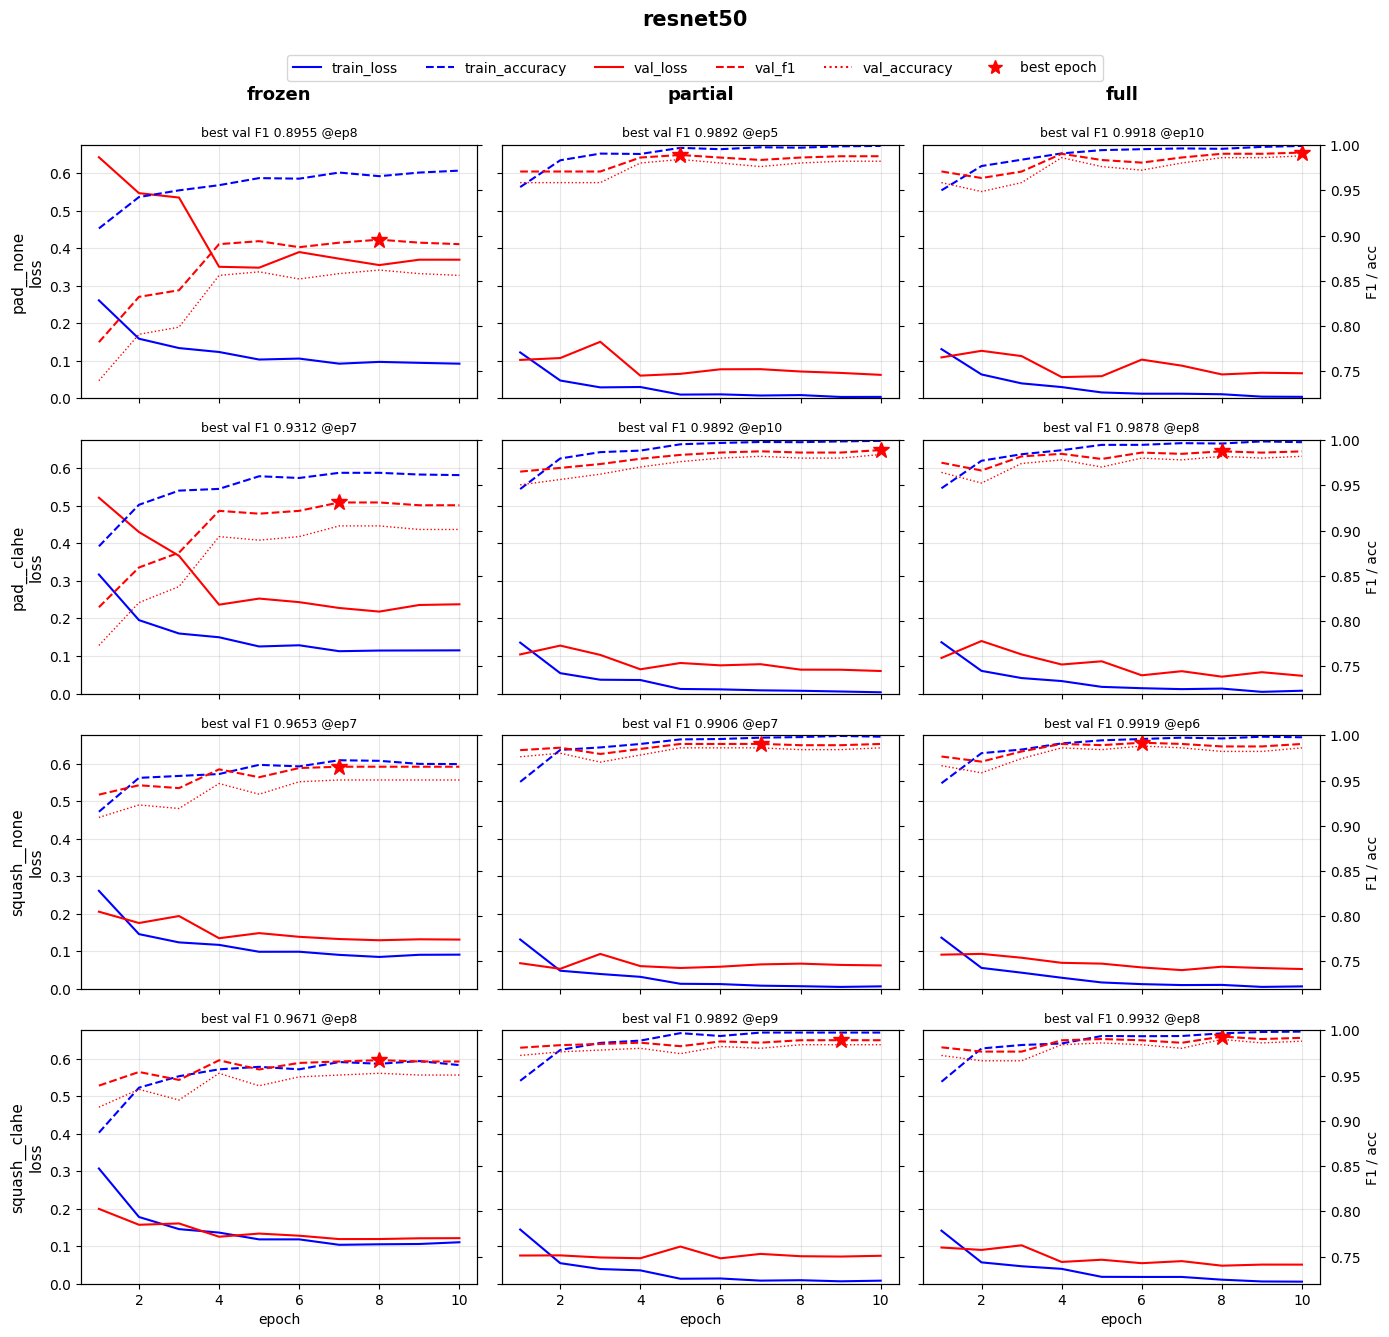

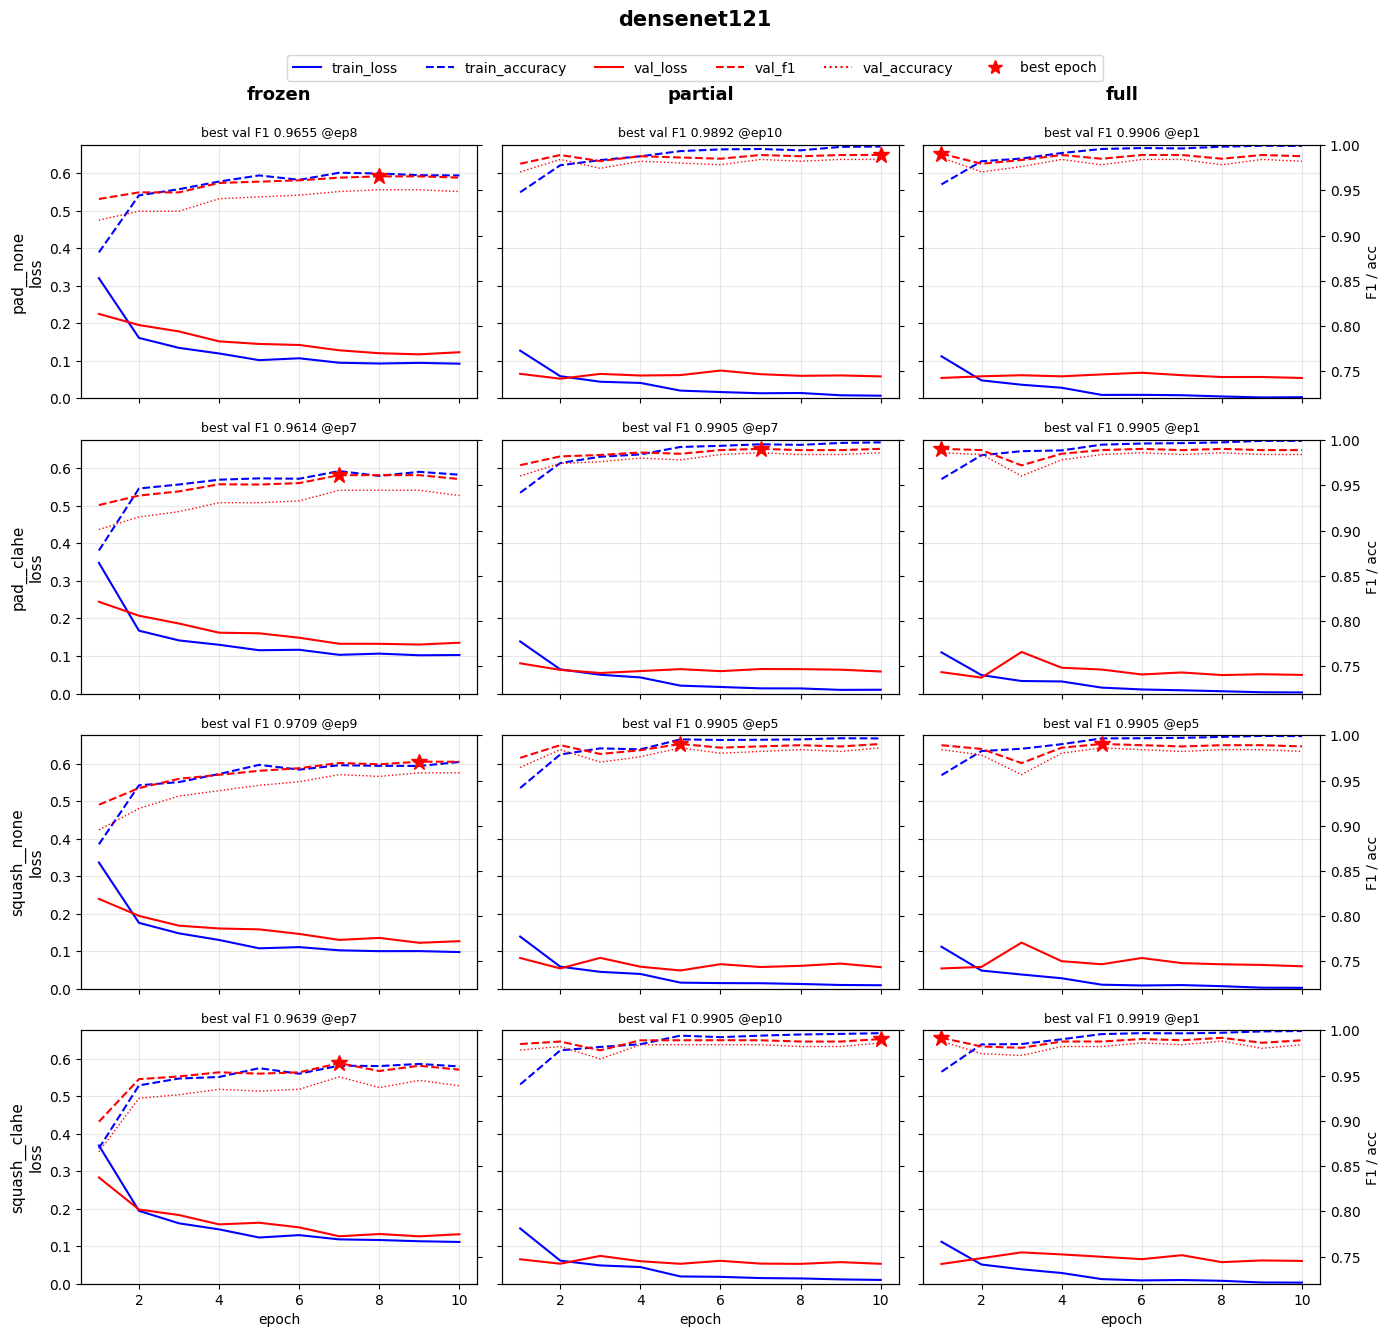

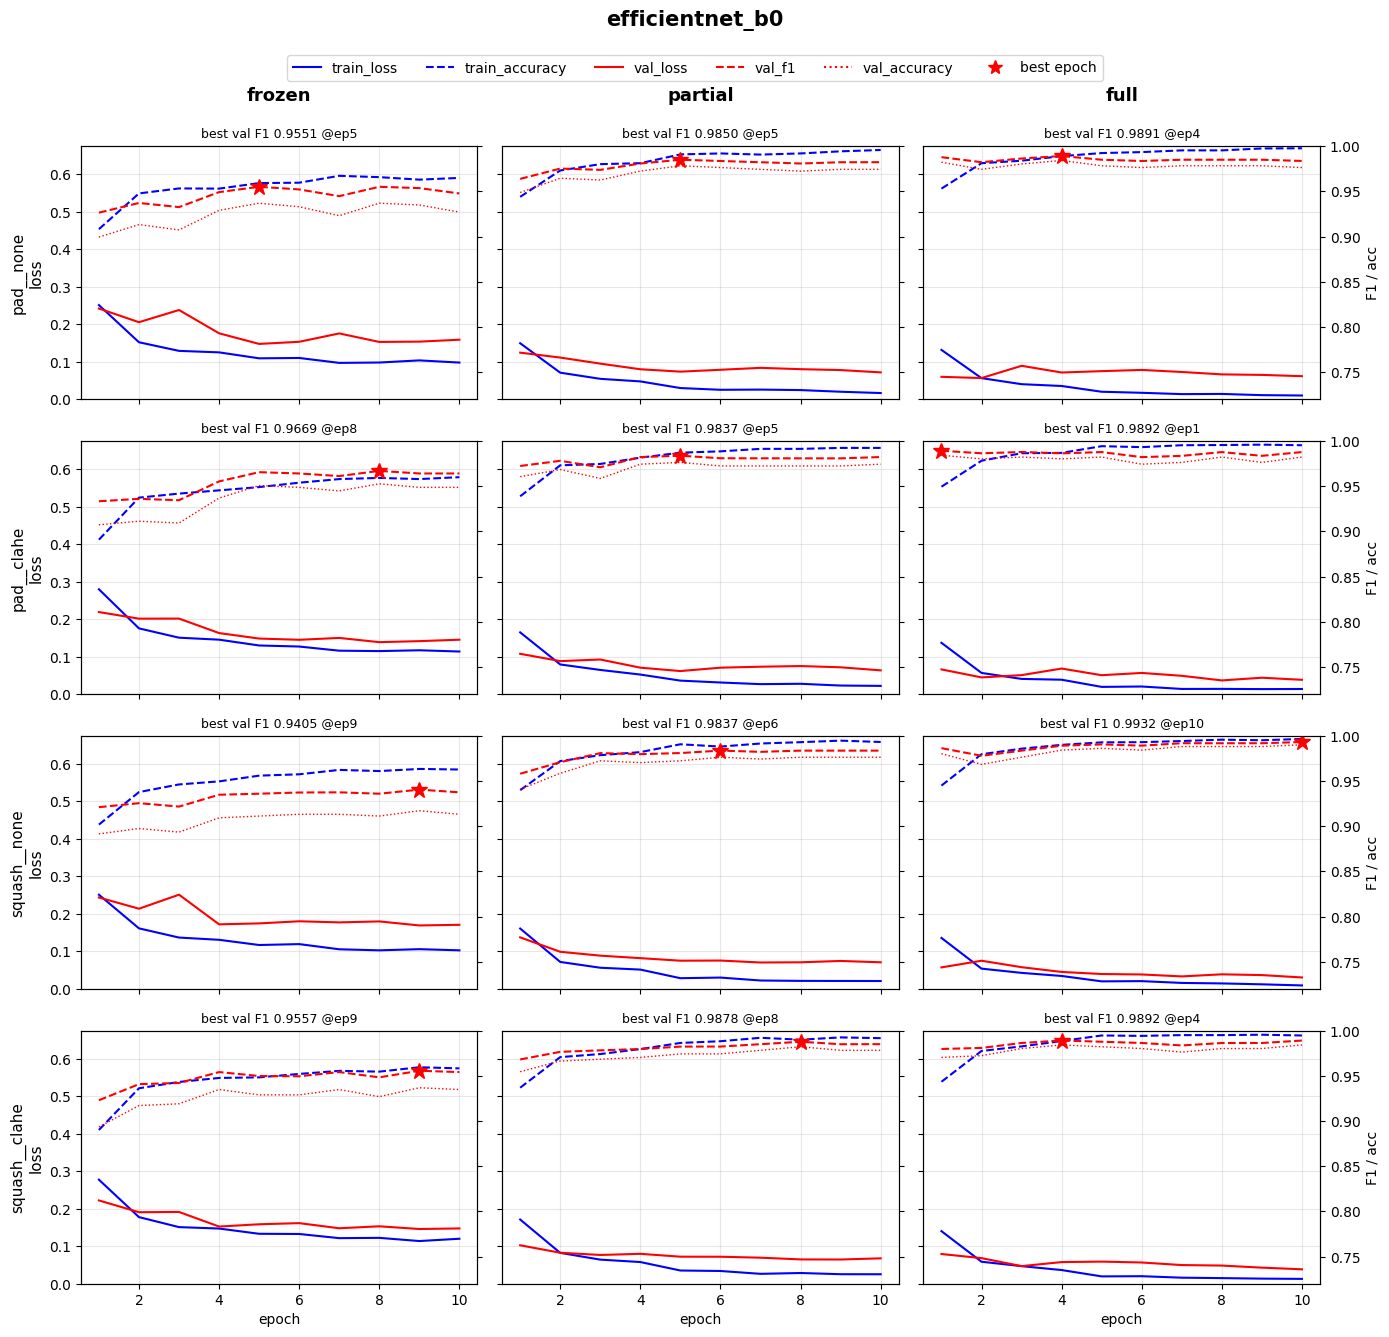

In [19]:
# 36개 run의 학습 곡선을 한 화면에 그려 비교한다. (TensorBoard를 켜지 않아도 확인 가능)
# 과적합, 학습률, 전처리 변형, 모델/모드별 성능 차이를 한눈에 볼 수 있다.
# - 도표
#   - 각 모델 별로 12개 그래프를 모두 그린다. 각 모델 별로 행으로는 데이터 전처리방식 4가지, 열로는 학습방식 3개지 grid로 그린다.
#   - 총 36개 그래프가 보인다.
#   - 각 그래프: x = epoch, y_1 = loss, y_2 = f1.
#   - 각 그래프에는 꺾은선이 총 4개 보인다. train_loss(파란색 실선), train_f1(파란색 점선), val_loss(빨간색 실선), val_f1(빨간색 점선)
#
# history/{run}.csv만 읽으므로 0장(상수/경로)만 실행하면 된다. ★ = best epoch(val F1 최고, _best.pt에 저장된 에폭).
# train F1은 학습 때 기록하지 않았으므로(history에 train_loss/train_accuracy만 있음) 그 자리에 train accuracy를 그린다.
#   이때는 비교 짝을 맞추려고 val accuracy(빨간 점선, 얇게)도 함께 그린다.
# 주의: train 지표는 WeightedRandomSampler(클래스 1:1) + 증강이 걸린 배치에서, val 지표는 원래 분포에서 계산된다.
#   그래서 train/val의 절대 차이를 그대로 과적합으로 읽지 말고, 에폭이 지나며 차이가 벌어지는지(추세)를 본다.
from matplotlib.lines import Line2D

ARCH_ORDER = ["resnet50", "densenet121", "efficientnet_b0"]
MODE_ORDER = ["frozen", "partial", "full"]
VARIANT_ORDER = ["pad__none", "pad__clahe", "squash__none", "squash__clahe"]


def load_histories(hist_dir: Path = HIST_DIR) -> pd.DataFrame:
    frames = []
    for path in sorted(hist_dir.glob("*.csv")):
        arch, mode, variant = path.stem.split("__", 2)
        sizing, clahe = variant.split("__")
        frames.append(pd.read_csv(path).assign(run=path.stem, arch=arch, mode=mode, variant=variant,
                                               sizing=sizing, clahe=clahe))
    return pd.concat(frames, ignore_index=True)


hist = load_histories()
n_epochs = hist.groupby("run")["epoch"].max()
print(f"history: {hist['run'].nunique()} / {len(ARCH_ORDER) * len(MODE_ORDER) * len(VARIANT_ORDER)} run")
if n_epochs.nunique() > 1:
    print("에폭 수가 다른(학습 중이던) run:", n_epochs[n_epochs < n_epochs.max()].to_dict())

TRAIN_SCORE = "train_f1" if "train_f1" in hist else "train_accuracy"
SCORE_COLS = [TRAIN_SCORE, "val_f1"] + ([] if TRAIN_SCORE == "train_f1" else ["val_accuracy"])
LOSS_MAX = hist[["train_loss", "val_loss"]].max().max() * 1.05
SCORE_MIN = max(0.0, np.floor((hist[SCORE_COLS].min().min() - 0.01) * 50) / 50)


def plot_curves(arch: str):
    fig, axes = plt.subplots(len(VARIANT_ORDER), len(MODE_ORDER), figsize=(14, 13), sharex=True, sharey=True)
    for i, variant in enumerate(VARIANT_ORDER):
        for j, mode in enumerate(MODE_ORDER):
            ax = axes[i, j]
            ax2 = ax.twinx()
            d = hist[(hist["arch"] == arch) & (hist["mode"] == mode) & (hist["variant"] == variant)].sort_values("epoch")
            if not d.empty:
                ax.plot(d["epoch"], d["train_loss"], "b-", lw=1.5)
                ax.plot(d["epoch"], d["val_loss"], "r-", lw=1.5)
                ax2.plot(d["epoch"], d[TRAIN_SCORE], "b--", lw=1.5)
                ax2.plot(d["epoch"], d["val_f1"], "r--", lw=1.5)
                if TRAIN_SCORE != "train_f1":
                    ax2.plot(d["epoch"], d["val_accuracy"], "r:", lw=1)
                best = d[d["is_best"]].iloc[-1]
                ax2.plot(best["epoch"], best["val_f1"], "r*", ms=12)
                ax.set_title(f"best val F1 {best['val_f1']:.4f} @ep{int(best['epoch'])}", fontsize=9)
            ax.set_ylim(0, LOSS_MAX)
            ax2.set_ylim(SCORE_MIN, 1.0)
            ax2.tick_params(labelright=(j == len(MODE_ORDER) - 1))
            ax.grid(alpha=0.3)
            if i == 0:
                ax.annotate(mode, (0.5, 1.18), xycoords="axes fraction", ha="center", fontsize=13, weight="bold")
            if j == 0:
                ax.set_ylabel(f"{variant}\nloss", fontsize=11)
            if j == len(MODE_ORDER) - 1:
                ax2.set_ylabel("F1" if TRAIN_SCORE == "train_f1" else "F1 / acc")
            if i == len(VARIANT_ORDER) - 1:
                ax.set_xlabel("epoch")
    handles = [Line2D([], [], color="b", ls="-", label="train_loss"),
               Line2D([], [], color="b", ls="--", label=TRAIN_SCORE),
               Line2D([], [], color="r", ls="-", label="val_loss"),
               Line2D([], [], color="r", ls="--", label="val_f1")]
    if TRAIN_SCORE != "train_f1":
        handles.append(Line2D([], [], color="r", ls=":", label="val_accuracy"))
    handles.append(Line2D([], [], color="r", marker="*", ls="", ms=10, label="best epoch"))
    fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.995))
    fig.suptitle(arch, y=1.025, fontsize=15, weight="bold")
    fig.tight_layout()
    plt.show()


for arch in ARCH_ORDER:
    plot_curves(arch)

## 4.1. 학습 곡선 평가

1. **발견**
    - **frozen이 partial, full보다 성능이 떨어진다.** 
        - frozen은 다른 학습방법들보다 갱신하는 가중치가 훨씬 적다. 즉, 사전학습 모델의 성능을 가장 많이 유지한다는 것이다. X-ray 사진으로 폐렴 여부를 판단하는 과제에서는 ImageNet에서 학습한 정보들이 크게 유의미하지 않았을 것이라고 판단할 수 있겠다. 
        - 그래프를 보면, frozen에서 train, validation loss가 시작하는 출발점이 partial, full에 비해 높은 것을 알 수 있다. 
        - 그리고, epoch 1에서의 loss와 epoch 10에서의 loss의 차이가 frozen에서 partial, full에 비해 크다. 즉, 학습이 더 많이 되었다는 것을 알 수 있고, ImageNet의 가중치에서 변경할 점이 더 많았을 것이라고 추측할 수 있다. 
    - **partial, full에서, train의 loss, acc 개선도에 비해 validation loss, f1 개선도가 더 작았다.** 
        - 즉, epoch이 진행됨에 따라 val loss, f1은 변화가 그렇게 크지 않았다는 것이다. 
        - ***이를 과적합 신호로 보기에는 무리가 있다.*** 
        - 왜냐하면 validation acc, f1이 모두 0.98정도로 일관되게 높았기 때문이다. 그리고 train loss는 줄어드는데 validation loss는 늘어나는 경우가 없었기 때문이다. 
    - **하지만 대부분의 경우에서 train loss가 수렴하는 기울기보다, validation loss가 수렴하는 기울기가 더 작았다.**
        - 이정도의 차이는 일반적인 것인 지, 아니면 이상 신호인 것인 지 분석 및 원인 분석이 필요하다. 
    - **ResNet50에서, padding으로 사이즈를 맞췄을 때, train과 validation loss와 acc, f1의 차이가 다른 경우보다 훨씬 컸다.**
        - 왜 굳이 ResNet50에서 이런 차이가 났는 지 분석해볼 가치가 있다. 

2. **한계**
    - colab 무료 계정과 드라이브 용량의 한계로 인해 epoch을 10까지밖에 하지 못했다. 리소스가 허용하는 한 30에폭까지는 돌려봐야 할 것으로 생각된다. 
    - 마찬가지 이유로 한 번의 train, validation만 기록한 결과다. 
    - train 기록에서 f1을 넣지 않았다. acc만 기록했다. recall, precision, f1, acc를 모두 기록해서 다시 한 번 점검해볼 필요가 있다. 
    - 

val 507장 (PNEUMONIA 369장) -> 1장 오분류가 F1을 약 0.0014 움직인다


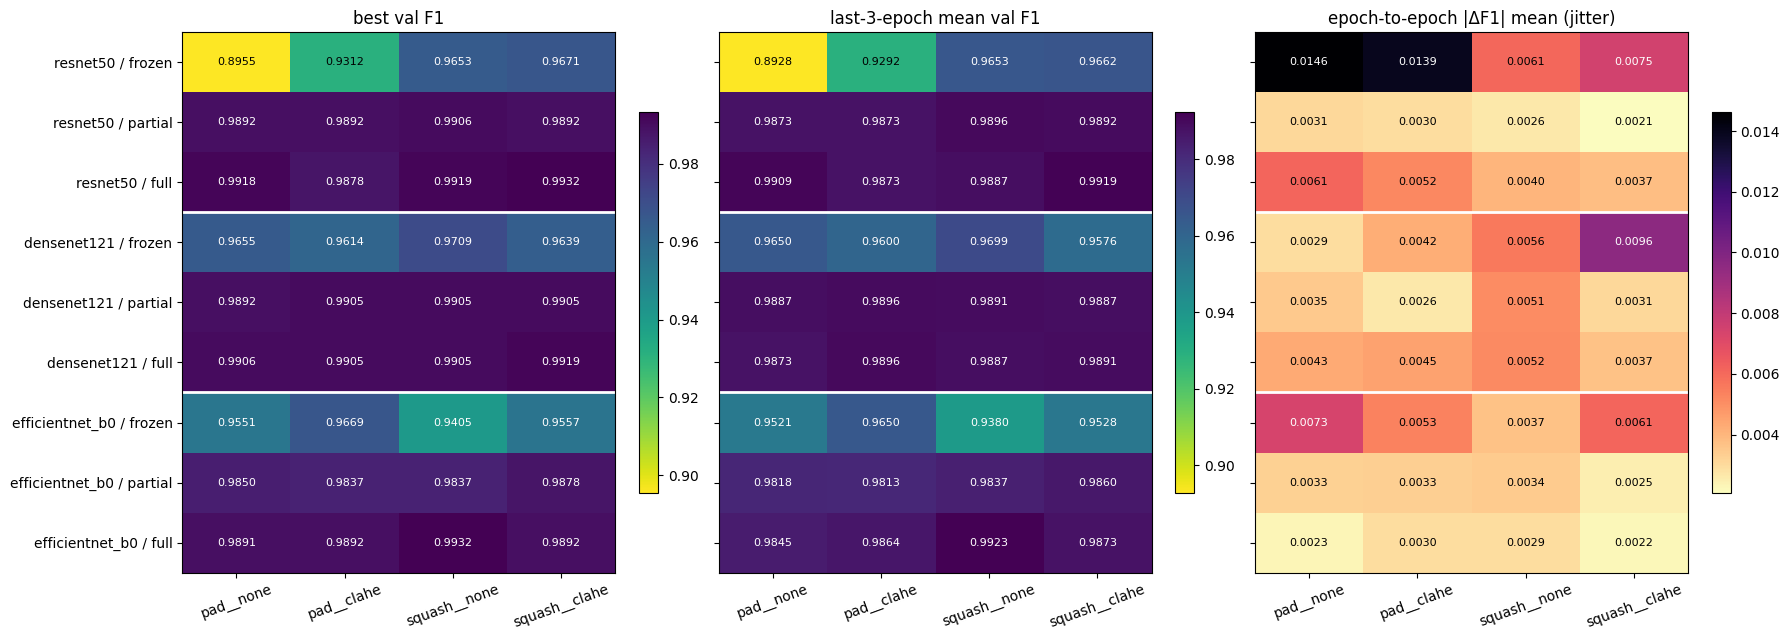

상위 10개 run (기준: last3_f1 = 마지막 3에폭 평균 val F1, 내림차순)


,run,best_epoch,best_f1,last3_f1,best_auc,jitter_f1
19,efficientnet_b0__full__squash__none,10,0.9932,0.9923,0.9993,0.0029
30,resnet50__full__squash__clahe,8,0.9932,0.9919,0.9976,0.0037
29,resnet50__full__pad__none,10,0.9918,0.9909,0.9974,0.0061
4,densenet121__full__pad__clahe,1,0.9905,0.9896,0.9973,0.0045
35,resnet50__partial__squash__none,7,0.9906,0.9896,0.9967,0.0026
8,densenet121__partial__pad__clahe,7,0.9905,0.9896,0.9970,0.0026
34,resnet50__partial__squash__clahe,9,0.9892,0.9892,0.9964,0.0021
6,densenet121__full__squash__clahe,1,0.9919,0.9891,0.9967,0.0037
11,densenet121__partial__squash__none,5,0.9905,0.9891,0.9983,0.0051
7,densenet121__full__squash__none,5,0.9905,0.9887,0.9978,0.0052


In [22]:
# ---------- run별 요약 히트맵: best val F1 / 마지막 3에폭 평균 val F1 / 에폭 간 흔들림 ----------
# best F1은 10개 에폭 중 최댓값이라 운 좋은 에폭 하나에 끌려갈 수 있다 -> 마지막 3에폭 평균(last3)을 함께 본다.
# jitter = 연속한 두 에폭 사이 val F1 변화량(절댓값)의 평균. 같은 설정 안에서 에폭마다 얼마나 흔들리는지.
# 행 = 모델 x 학습방식(9), 열 = 전처리 변형(4). 색은 패널마다 따로 스케일한다.
# 색 방향: 모든 패널에서 짙을수록 값이 크다 (F1은 짙을수록 좋고, jitter는 짙을수록 많이 흔들린다).
def summarize_runs(hist: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for run, d in hist.groupby("run", sort=False):
        d = d.sort_values("epoch")
        best = d[d["is_best"]].iloc[-1]
        rows.append({"run": run, **d.iloc[0][["arch", "mode", "variant", "sizing", "clahe"]].to_dict(),
                     "best_epoch": int(best["epoch"]), "best_f1": best["val_f1"], "best_auc": best["val_roc_auc"],
                     "last3_f1": d["val_f1"].tail(3).mean(),
                     "jitter_f1": d["val_f1"].diff().abs().mean()})
    return pd.DataFrame(rows)


runs = summarize_runs(hist)

# val 1장을 더 틀리면 F1이 얼마나 변하나: F1 = 2TP / (2TP + FP + FN) -> 분모가 1 늘 때 약 F1 / (2TP + FP + FN)
_v = hist.iloc[0]
n_val, n_val_pos = int(_v[["val_tn", "val_fp", "val_fn", "val_tp"]].sum()), int(_v["val_fn"] + _v["val_tp"])
ONE_SAMPLE_F1 = 1 / (2 * n_val_pos)
print(f"val {n_val}장 (PNEUMONIA {n_val_pos}장) -> 1장 오분류가 F1을 약 {ONE_SAMPLE_F1:.4f} 움직인다")

PANELS = [("best_f1", "best val F1", "viridis_r"), ("last3_f1", "last-3-epoch mean val F1", "viridis_r"),
          ("jitter_f1", "epoch-to-epoch |ΔF1| mean (jitter)", "magma_r")]
row_keys = [(a, m) for a in ARCH_ORDER for m in MODE_ORDER]
fig, axes = plt.subplots(1, len(PANELS), figsize=(18, 6.5))
for ax, (col, title, cmap) in zip(axes, PANELS):
    mat = (runs.pivot_table(index=["arch", "mode"], columns="variant", values=col)
           .reindex(index=pd.MultiIndex.from_tuples(row_keys), columns=VARIANT_ORDER))
    im = ax.imshow(mat.values, cmap=cmap, aspect="auto")
    for (r, c), v in np.ndenumerate(mat.values):
        if not np.isnan(v):
            ax.text(c, r, f"{v:.4f}", ha="center", va="center", fontsize=8,
                    color="white" if np.dot(im.cmap(im.norm(v))[:3], [0.299, 0.587, 0.114]) < 0.5 else "black")
    ax.set_xticks(range(len(VARIANT_ORDER)), VARIANT_ORDER, rotation=20)
    ax.set_yticks(range(len(row_keys)), [f"{a} / {m}" for a, m in row_keys] if ax is axes[0] else [])
    for k in range(1, len(ARCH_ORDER)):
        ax.axhline(k * len(MODE_ORDER) - 0.5, color="white", lw=2)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
plt.show()

# 표: last3_f1(마지막 3에폭 평균 val F1) 내림차순 상위 10개 run. best_f1 열은 정렬 기준이 아니다.
TOP_K = 10
print(f"상위 {TOP_K}개 run (기준: last3_f1 = 마지막 3에폭 평균 val F1, 내림차순)")
display(runs.sort_values("last3_f1", ascending=False)
        [["run", "best_epoch", "best_f1", "last3_f1", "best_auc", "jitter_f1"]].head(TOP_K).round(4))

## 4.2. 가장 성능이 좋았던 조합

- **발견**
    - 히트맵에서 가장 어두운 부분이 가장 성능이 좋았던 부분이다. **단일 best validation F1, last 3-epoch mean of validation F1 모두 EfficientNetB0 + full fintuning + squash Resizing + CLAHE 미적용이 가장 좋았다.**
        - 하지만 ResNet Frozen, DenseNet Frozen, EfficientNet Frozen을 제외하고는 거의 성능이 비슷하다. 
    - **full finetuning의 성능이 partial finetuning보다 좋았다.** 
        - 상위 10개 run 중 6개가 full fine tuning이었고, 상위 5개 중 4개가 full finetuning이었다. 
        - 상위 10개 run 중에 Frozen은 끼지 못했다. 

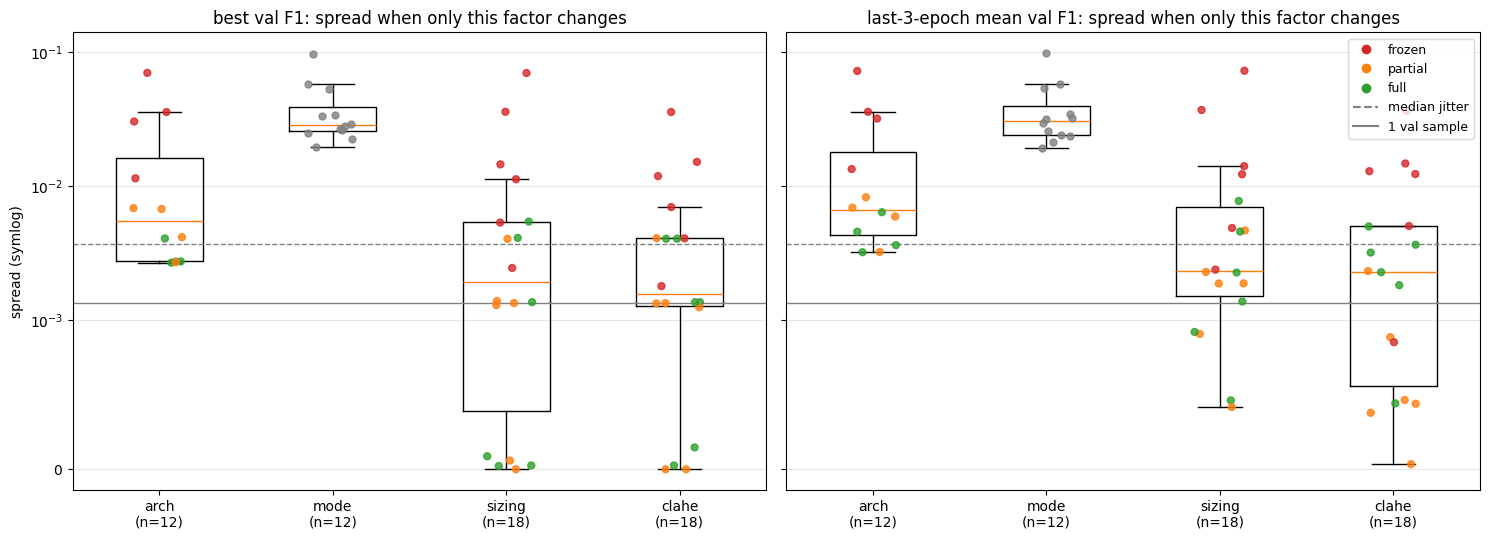

count    mean  median     max
best val F1              arch     12.0  0.0150  0.0055  0.0700
                         mode     12.0  0.0376  0.0285  0.0963
                         sizing   18.0  0.0088  0.0019  0.0698
                         clahe    18.0  0.0053  0.0016  0.0357
last-3-epoch mean val F1 arch     12.0  0.0163  0.0067  0.0723
                         mode     12.0  0.0377  0.0306  0.0982
                         sizing   18.0  0.0096  0.0023  0.0726
                         clahe    18.0  0.0057  0.0023  0.0364

흔들림 큰 순서 (last3 F1 spread 중앙값): mode(0.0306) > arch(0.0067) > sizing(0.0023) > clahe(0.0023)



#### sizing: **squash** vs **pad**
같은 모델·학습방식·나머지 전처리에서 sizing만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = squash 지표 − pad 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = 18짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| squash 승 | 차이 ≥ +0.0014 (val 1장 이상 더 맞힘): **squash 쪽이 더 좋았던** 짝 수 |
| pad 승 | 차이 ≤ −0.0014: **pad 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \|차이\| < 0.0014: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 (squash-pad) | 차이의 평균. 양수면 평균적으로 squash 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 (pad 최대 우세) | 가장 작은 차이. 음수면 pad 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 (squash 최대 우세) | 가장 큰 차이. 양수면 squash 쪽이 가장 크게 이긴 짝의 격차 |


짝 수  squash 승  pad 승  실질 동률  \
지표                       범위                                     
best val F1              전체        18         9      2      7   
                         frozen     6         4      2      0   
                         partial    6         2      0      4   
                         full       6         3      0      3   
last-3-epoch mean val F1 전체        18        10      4      4   
                         frozen     6         3      3      0   
                         partial    6         4      0      2   
                         full       6         3      1      2   

                                  평균 차이 (squash-pad)  최소 (pad 최대 우세)  \
지표                       범위                                            
best val F1              전체                   0.0058         -0.0145   
                         frozen               0.0146         -0.0145   
                         partial              0.0009         -0.0013   
                         full                 0.0018         -0.0001   
last-3-epoch mean val F1 전체                   0.0060         -0.0141   
                         frozen               0.0143         -0.0141   
                         partial              0.0017         -0.0009   
                         full                 0.0020         -0.0023   

                                  최대 (squash 최대 우세)  
지표                       범위                          
best val F1              전체                  0.0698  
                         frozen              0.0698  
                         partial             0.0040  
                         full                0.0054  
last-3-epoch mean val F1 전체                  0.0726  
                         frozen              0.0726  
                         partial             0.0047  
                         full                0.0078


#### clahe: **clahe** vs **none**
같은 모델·학습방식·나머지 전처리에서 clahe만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = clahe 지표 − none 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = 18짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| clahe 승 | 차이 ≥ +0.0014 (val 1장 이상 더 맞힘): **clahe 쪽이 더 좋았던** 짝 수 |
| none 승 | 차이 ≤ −0.0014: **none 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \|차이\| < 0.0014: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 (clahe-none) | 차이의 평균. 양수면 평균적으로 clahe 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 (none 최대 우세) | 가장 작은 차이. 음수면 none 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 (clahe 최대 우세) | 가장 큰 차이. 양수면 clahe 쪽이 가장 크게 이긴 짝의 격차 |


짝 수  clahe 승  none 승  실질 동률  \
지표                       범위                                     
best val F1              전체        18        7       4      7   
                         frozen     6        4       2      0   
                         partial    6        1       0      5   
                         full       6        2       2      2   
last-3-epoch mean val F1 전체        18        7       4      7   
                         frozen     6        3       2      1   
                         partial    6        1       0      5   
                         full       6        3       2      1   

                                  평균 차이 (clahe-none)  최소 (none 최대 우세)  \
지표                       범위                                             
best val F1              전체                   0.0028          -0.0070   
                         frozen               0.0089          -0.0070   
                         partial              0.0005          -0.0013   
                         full                -0.0009          -0.0041   
last-3-epoch mean val F1 전체                   0.0027          -0.0123   
                         frozen               0.0079          -0.0123   
                         partial              0.0003          -0.0005   
                         full                -0.0002          -0.0050   

                                  최대 (clahe 최대 우세)  
지표                       범위                         
best val F1              전체                 0.0357  
                         frozen             0.0357  
                         partial            0.0041  
                         full               0.0014  
last-3-epoch mean val F1 전체                 0.0364  
                         frozen             0.0364  
                         partial            0.0023  
                         full               0.0032

In [23]:
# ---------- 어떤 변수가 결과를 가장 크게 흔드는가 ----------
# 변수 하나만 바꾸고 나머지 세 변수는 고정한 짝끼리 비교한다.
#   예) sizing: 같은 (arch, mode, clahe)의 pad vs squash -> 18짝 / clahe: 18짝 / arch: 같은 (mode, variant)의 3모델 -> 12묶음 / mode: 12묶음
# spread = 그 묶음 안에서 지표의 (최댓값 - 최솟값). 분포가 위에 있을수록 그 변수가 결과를 크게 흔든다.
# 회색 점선 = run 내부 에폭 간 흔들림(jitter)의 중앙값, 회색 실선 = val 1장 오분류 크기.
#   spread가 이 선들 근처라면 그 변수의 효과는 에폭/표본 운과 구분하기 어렵다 (-> 반복 실험(k-fold/시드)이 필요한 변수).
FACTORS = ["arch", "mode", "sizing", "clahe"]
MODE_COLORS = {"frozen": "tab:red", "partial": "tab:orange", "full": "tab:green"}


def factor_groups(runs: pd.DataFrame, factor: str):
    """factor만 다르고 나머지 변수가 같은 run 묶음들"""
    return runs.groupby([f for f in FACTORS if f != factor])


def factor_spread(runs: pd.DataFrame, factor: str, value: str) -> pd.DataFrame:
    g = factor_groups(runs, factor)[value]
    return pd.DataFrame({"spread": g.max() - g.min()}).reset_index()


METRICS = [("best_f1", "best val F1"), ("last3_f1", "last-3-epoch mean val F1")]
fig, axes = plt.subplots(1, len(METRICS), figsize=(15, 5.5), sharey=True)
rng = np.random.default_rng(0)
table = {}
for ax, (value, title) in zip(axes, METRICS):
    spreads = [factor_spread(runs, f, value) for f in FACTORS]
    ax.boxplot([s["spread"] for s in spreads], showfliers=False, widths=0.5)
    for k, (f, s) in enumerate(zip(FACTORS, spreads), start=1):
        colors = "gray" if f == "mode" else s["mode"].map(MODE_COLORS)
        ax.scatter(k + rng.uniform(-0.15, 0.15, len(s)), s["spread"], c=colors, s=25, alpha=0.8, zorder=3)
        table[(title, f)] = s["spread"].describe()[["count", "mean", "50%", "max"]]
    ax.axhline(runs["jitter_f1"].median(), color="gray", ls="--", lw=1)
    ax.axhline(ONE_SAMPLE_F1, color="gray", ls="-", lw=1)
    ax.set_xticks(range(1, len(FACTORS) + 1), [f"{f}\n(n={len(s)})" for f, s in zip(FACTORS, spreads)])
    ax.set_yscale("symlog", linthresh=1e-3)   # spread=0(동률)도 보이도록 0 근처는 선형
    ax.set_title(f"{title}: spread when only this factor changes")
    ax.grid(alpha=0.3, axis="y")
axes[0].set_ylabel("spread (symlog)")
axes[-1].legend(handles=[Line2D([], [], color=c, marker="o", ls="", label=m) for m, c in MODE_COLORS.items()]
                + [Line2D([], [], color="gray", ls="--", label="median jitter"),
                   Line2D([], [], color="gray", ls="-", label="1 val sample")],
                loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

spread_table = pd.DataFrame(table).T.rename(columns={"50%": "median"})
display(spread_table.round(4))
rank = spread_table.loc["last-3-epoch mean val F1"].sort_values("median", ascending=False)
print("흔들림 큰 순서 (last3 F1 spread 중앙값):", " > ".join(f"{f}({v:.4f})" for f, v in rank["median"].items()))

# 두 수준짜리 변수(sizing, clahe)는 방향도 본다: 다른 변수가 모두 같은 run 짝마다 (B - A)를 계산한다.
# |차이|가 val 1장 오분류 크기(ONE_SAMPLE_F1)보다 작으면 우연과 구분할 수 없으므로 승패 대신 '실질 동률'로 센다.
from IPython.display import Markdown


def head_to_head(factor: str, a: str, b: str) -> pd.DataFrame:
    others = [f for f in FACTORS if f != factor]
    rows = []
    for value, title in METRICS:
        w = runs.pivot_table(index=others, columns=factor, values=value)
        diff = w[b] - w[a]
        for scope, dd in [("전체", diff)] + [(m, diff.xs(m, level="mode")) for m in MODE_ORDER]:
            rows.append({"지표": title, "범위": scope, "짝 수": len(dd),
                         f"{b} 승": int((dd >= ONE_SAMPLE_F1).sum()),
                         f"{a} 승": int((dd <= -ONE_SAMPLE_F1).sum()),
                         "실질 동률": int((dd.abs() < ONE_SAMPLE_F1).sum()),
                         f"평균 차이 ({b}-{a})": dd.mean(),
                         f"최소 ({a} 최대 우세)": dd.min(), f"최대 ({b} 최대 우세)": dd.max()})
    return pd.DataFrame(rows).set_index(["지표", "범위"]).round(4)


for factor, a, b in [("sizing", "pad", "squash"), ("clahe", "none", "clahe")]:
    n_pairs = len(runs) // 2
    display(Markdown(f"""
#### {factor}: **{b}** vs **{a}**
같은 모델·학습방식·나머지 전처리에서 {factor}만 다른 run 두 개를 한 짝으로 묶고, 짝마다 **차이 = {b} 지표 − {a} 지표**를 계산한다.

| 컬럼 | 의미 |
|--|--|
| 지표 | 비교에 쓴 값. best val F1 = 10에폭 중 최고 val F1, last-3-epoch mean val F1 = 마지막 3에폭 평균 val F1 |
| 범위 | 전체 = {n_pairs}짝 전부, frozen/partial/full = 그 학습방식의 짝만 |
| 짝 수 | 비교한 짝의 개수 |
| {b} 승 | 차이 ≥ +{ONE_SAMPLE_F1:.4f} (val 1장 이상 더 맞힘): **{b} 쪽이 더 좋았던** 짝 수 |
| {a} 승 | 차이 ≤ −{ONE_SAMPLE_F1:.4f}: **{a} 쪽이 더 좋았던** 짝 수 |
| 실질 동률 | \\|차이\\| < {ONE_SAMPLE_F1:.4f}: val 1장 오분류보다 작은 차이라 우열을 가릴 수 없는 짝 수 |
| 평균 차이 ({b}-{a}) | 차이의 평균. 양수면 평균적으로 {b} 쪽이 높다 (큰 짝 하나에 끌려갈 수 있으니 승패 수와 함께 본다) |
| 최소 ({a} 최대 우세) | 가장 작은 차이. 음수면 {a} 쪽이 가장 크게 이긴 짝의 격차 |
| 최대 ({b} 최대 우세) | 가장 큰 차이. 양수면 {b} 쪽이 가장 크게 이긴 짝의 격차 |
"""))
    display(head_to_head(factor, a, b))

## 4.3. 결과에 가장 많은 영향을 준 요인

1. **발견**
    - **전이학습 성능에 가장 영향을 많이 준 순서: 학습 설정(Frozen/Partial/Full) > arch(ResNet/DenseNet/EfficientNet) > sizing(pad/sqaush) > clahe(yes/no)**
    - **arch, sizing, clahe 각각에 변화를 줬을 때 가장 민감하게 반응한 것은 Frozen 학습방식이다.**
        - Partial, Full은 비슷한 민감도로 반응했다.  
    - **sizing: frozen, partial, full 모두에서 squash가 pad보다 성능이 좋았다.**
        - 다만 평균 차이가 전체 기준 0.0058로, validation을 약 4장정도 더 맞췄을 뿐이다. 
        - 한 장 더 틀리거나 맞췄을 때 나는 차이 수준: 0.0014
        - 따라서 sizing 축은 K-Fold Cross Validation으로 확정할 필요가 있다. 
    - **CLAHE: 대부분의 경우 CLAHE가 우세하다.**
        - 하지만 이도 sizing과 마찬가지로 validation 약 2장 더 맞췄을 정도일 뿐이다. 
        - 따라서 K-Fold Cross valdation으로 확정할 필요가 있다. 

2. **결론**
    - arch, mode 축을 EfficientNet, Full로 고정하고 sizing, clahe 축을 옮기면서 5-Fold Cross Validation을 진행해서 성능의 평균과 표준편차를 확인한다. 

# 4. K-Fold Cross validation: 애매한 쪽을 cross validation으로 확실하게 

# 6. Test 평가
- test 지표 표, confusion matrix, bacteria/virus별 오분류 분석, 필요하면 Grad-CAM으로 모델이 폐가 아닌 곳을 보는지 확인한다.